# High-Fidelity HCl-Aluminum Reactor Model (Phase 1 & Phase 2)

This notebook simulates the semi-batch synthesis of aqueous $AlCl_{3}$ under two distinct operating paradigms:
1. **Phase 1: Pure Superheated Feed:** A 32 wt% HCl / Steam mixture sparged over solid aluminum foil balls.
2. **Phase 2: Gasification Syngas Feed:** A multi-component gas stream ($H_2, CO, CO_2, N_2, H_2O, HCl$) representing raw gasifier output; the large inert carrier flow dramatically alters stripping, thermal limits, and vaporization curves.

### Physical Models & Engineering Corrections
*   **Absolute State-Path Enthalpies:** All feed species use Shomate-integral $\Delta H$ from 298.15 K reference.
*   **Raoult's Law Vapour Pressure Suppression:** $P_{brine} = P^*_{H_2O}(T) \cdot x_{H_2O}$.
*   **Shrinking-Core Kinetics with Arrhenius Temperature Correction:**
    $$r = k_{rate} \cdot e^{-E_A/R\,(1/T - 1/T_{ref})} \cdot m_{HCl} \cdot n_{Al}^{2/3} \qquad T_{ref} = 298.15\,K$$
    $k_{rate}$ is the user-facing slider value, calibrated at 25 °C. Effective rate approximately doubles every 20 K at typical operating temperatures.
*   **Dynamic Jacket Heat Transfer:** Jacket UA updates at every ODE timestep from the live brine height via the NTU-effectiveness method.
*   **Quadratic Brine Density:** $\rho = 1000 + 560w + 320w^2$ kg/m³ (fitted to $AlCl_3$ data, replaces over-estimating linear model).
*   **Aqueous Speciation:** pH trajectory computed from 15 PHREEQC snapshots (LLNL database).

### Key Assumptions
| Assumption | Justification / Limitation |
|---|---|
| Well-mixed liquid bath (CSTR) | Agitation or vigorous sparging assumed; plug-flow effects neglected |
| Antoine equation (1–100 °C) extrapolated to 150 °C | ±1 % error at 115 °C — acceptable for design |
| Shomate H₂O(g) set valid above 500 K | ±3 % error when applied from 298 K; conservative |
| Kinetic pre-exponential $k_{rate}$ measured at 25 °C | Re-calibrate slider if experiment was run at a different reference temperature |
| Vessel wall fully mixed at single temperature | Radial gradients neglected |
| Ideal-gas feed composition (SCFM → mol/s via $n = PV/RT$ at STP) | 1 SCFM = 1.198 mol/s |


In [1]:
# @title Install Dependencies & Setup
!pip install -q phreeqpython scipy matplotlib numpy graphviz pandas ipywidgets reportlab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass
from phreeqpython import PhreeqPython
import ipywidgets as widgets
from IPython.display import display, HTML
from graphviz import Digraph
import warnings
warnings.filterwarnings('ignore')

print("✅ Dependencies Loaded Successfully.")

# Pre-initialize PHREEQC globally to avoid repeated loading
try:
    pp = PhreeqPython(database='llnl.dat')
except:
    pp = PhreeqPython(database='phreeqc.dat')
print("✅ PHREEQC Geochemical Engine Loaded.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.1/811.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00
✅ Dependencies Loaded Successfully.
✅ PHREEQC Geochemical Engine Loaded.


### Cell 2: Rigorous Thermodynamic Core (NIST Shomate Engine)

All gas and liquid heat capacities and enthalpy integrals are computed using the **NIST Shomate Equation**, a 5-term polynomial that is valid over broad temperature ranges:

$$C_p(T) = A + Bt + Ct^2 + Dt^3 + \frac{E}{t^2}, \quad t = \frac{T}{1000}$$

The **sensible heat** carried by each feed stream from reference temperature $T_0 = 298.15\,K$ to feed temperature $T_{feed}$ is:

$$H_{sensible} = \int_{T_0}^{T_{feed}} C_p(T)\,dT = \dot{n}_{i} \cdot \Delta H_{Shomate}(T_0, T_{feed})$$

**Water vapor pressure** uses the Antoine Equation clipped to $[0.1°C, 150°C]$, then suppressed by the water mole fraction via **Raoult's Law**:

$$P_{vap} = 10^{\left(8.07131 - \frac{1730.63}{T + 233.426}\right)} \times \chi_{H_2O}$$

where $\chi_{H_2O} = n_{H_2O} / (n_{H_2O} + 2n_{HCl} + 4n_{AlCl_3})$ accounts for chloride salt suppression of the vapor activity.

**Brine level** is computed from a density model calibrated to AlCl$_3$ brine:

$$\rho_{brine} = 1000 + 800 \cdot w_{salts} \quad [kg/m^3]$$

$$h_{brine} = \frac{V_{brine}}{A_{vessel}} = \frac{m_{total}/\rho_{brine}}{\pi (D/2)^2}$$

**PHREEQC Speciation** is called at 15 sparse time points across the ODE solution arc, feeding the instantaneous $[Al^{3+}]$ and $[Cl^-]$ molalities into the LLNL.dat thermodynamic database to return the equilibrium pH.


In [2]:
# @title NIST Shomate Engine & Physical Constants
import numpy as np
from dataclasses import dataclass

@dataclass
class Shomate:
    """NIST Shomate polynomial for Cp and enthalpy integrals.
    Reference: https://webbook.nist.gov/chemistry/
    Valid within the temperature range stated at each instantiation.
    """
    A: float; B: float; C: float; D: float; E: float

    def cp(self, T_K):
        t = T_K / 1000.0
        return self.A + self.B*t + self.C*t**2 + self.D*t**3 + self.E/t**2

    def enthalpy_integral(self, T1, T2):
        """Returns H(T2) - H(T1) in J/mol (Shomate H equation × 1000)."""
        def _H(t):
            return self.A*t + self.B*t**2/2 + self.C*t**3/3 + self.D*t**4/4 - self.E/t
        t1, t2 = T1/1000.0, T2/1000.0
        return (_H(t2) - _H(t1)) * 1000.0


# ── NIST Shomate coefficients (valid ranges noted) ────────────────────────────
shomate_H2O_l = Shomate(-203.606,  1523.290, -3196.413,  2474.455,   3.855)  # 298–500 K
shomate_H2O_g = Shomate(  30.092,     6.832,     6.793,    -2.534,   0.082)  # 500–1700 K *
shomate_HCl_g = Shomate(  32.123,   -13.458,    19.868,    -6.853,  -0.049)  # 298–1200 K
shomate_H2_g  = Shomate(  33.066,   -11.363,    11.432,    -2.772,  -0.158)  # 298–1000 K
shomate_CO_g  = Shomate(  25.567,     6.096,     4.054,    -2.671,   0.131)  # 298–1200 K
shomate_CO2_g = Shomate(  24.997,    55.186,   -33.691,     7.948,  -0.136)  # 298–1200 K
shomate_N2_g  = Shomate(  26.092,     8.218,    -1.976,     0.159,   0.044)  # 298–2000 K
# * shomate_H2O_g is applied from 298 K for steam feed enthalpy (±3 % error below 500 K)


# ── Molecular weights [kg/mol] ────────────────────────────────────────────────
MW = {'Al': 0.02698, 'HCl': 0.03646, 'H2': 0.002016, 'H2O': 0.01802, 'AlCl3': 0.13334}


# ── Reaction thermodynamics ───────────────────────────────────────────────────
# Enthalpy of 2Al + 6HCl(aq) → 2AlCl3(aq) + 3H2:
#   dH_rxn_Al = 524.5 kJ/mol-Al   (solid-phase dissolution only)
#   dH_solv_HCl × 3 = 224.5 kJ/mol-Al  (HCl solvation)
#   Combined ≈ 749 kJ/mol-Al  vs NIST literature 755.9 kJ/mol-Al  (0.9 % error)
dH_rxn_Al_J_mol   = 531_500.0  # J/mol-Al  (NIST: 2Al+6HCl(aq)→2AlCl₃(aq)+3H₂; 531.5 kJ/mol-Al; combined w/ solvation = 756 kJ/mol-Al)
dH_solv_HCl_J_mol =  74_840.0  # J/mol-HCl
dH_cond_H2O_J_mol =  44_000.0  # J/mol-H2O  (condensation at 298 K reference)


# ── Arrhenius kinetics ────────────────────────────────────────────────────────
R_GAS   = 8.314     # J/(mol·K)
E_A_AL  = 45_000.0  # J/mol  — activation energy for Al dissolution in HCl(aq)
                    #   Literature: 40–55 kJ/mol; 45 kJ/mol is a mid-range estimate.
                    #   Implies ~2× rate increase per 20 K at typical bath temps.
T_REF_K = 298.15    # K  — reference temperature for k_rate slider


def arrhenius_k(k_ref, T_K):
    """Apply Arrhenius correction to a rate constant calibrated at T_REF_K.

    k(T) = k_ref · exp[−E_A / R · (1/T − 1/T_ref)]

    The k_rate slider retains its original meaning (rate at 25 °C).
    Typical correction: ×1.4 at 40°C, ×5 at 60°C, ×16 at 80°C.
    """
    return k_ref * np.exp(-E_A_AL / R_GAS * (1.0/T_K - 1.0/T_REF_K))


# ── Unit conversions (module-level to eliminate repeated magic numbers) ────────
GPM_TO_KG_S   = 3.785411784 / 60.0   # 1 US GPM liquid water → kg/s
LB_TO_KG      = 0.453592             # lbs → kg
SCFM_TO_MOL_S = 1.198 / 60.0        # 1 SCFM ideal gas → mol/s  (STP basis)
SCF_TO_MOL    = 1.198               # 1 SCF ideal gas → mol

# ── Oxide layer / passivation parameters ────────────────────────────────────────────
E_A_OX             = 70_000.0   # J/mol  — Al₂O₃ dissolution activation energy
                                 #   Literature range: 60–80 kJ/mol (HCl(aq) systems)
k_OXIDE_REF        =   0.003    # kg/(mol·s) @ T_REF_K — oxide dissolution rate constant
                                 #   Calibrated to 5–20 min induction at ~1 M HCl, 25 °C
OXIDE_FRAC_0       =   1.0      # Initial normalised oxide thickness (1=passivated, 0=bare)

# ── Thermal runaway detection thresholds ────────────────────────────────────────
T_RUNAWAY_C        = 115.0      # °C — HCl/H₂O azeotrope boiling point (hard limit)
T_WARNING_C        =  80.0      # °C — pre-alarm operational temperature
DTDT_WARNING_C_MIN =   2.0      # °C/min — rate-of-rise warning threshold
HCL_INVENTORY_WARN =  10.0      # mol — HCl at oxide breakthrough warranting runaway flag


# ── Simulation constants ──────────────────────────────────────────────────────
T_SIM_SECONDS       = 14_400   # total run time [s]  = 4 hours
N_ODE_POINTS        = 2_000    # t_eval resolution
INITIAL_WATER_GAL   = 12.0     # initial water charge [US gallons]


# ── Vessel geometry & thermal properties ─────────────────────────────────────
vessel_dia_m    = 17.5 * 0.0254                        # inner diameter [m]
vessel_area_m2  = np.pi * (vessel_dia_m / 2.0)**2     # cross-section [m²]
vessel_height_m = 24.0 * 0.0254                        # max jacket-wetted height [m]
mass_vessel_kg  = 115.0
Cp_vessel       = 500.0    # J/(kg·K)  steel
Cp_salt_aq      = 3_000.0  # J/(kg·K)  aqueous salt solution
Cp_Al_solid     = 896.0    # J/(kg·K)  aluminium
Cp_HCl_aq_J_molK =  75.0   # J/(mol·K)  partial molar Cp of HCl(aq), literature 50–80 J/(mol·K)


# ── Physical property functions ───────────────────────────────────────────────
def vapor_pressure_water_atm(T_C, x_water):
    """Antoine equation + Raoult's Law mole-fraction correction.
    Antoine constants valid 1–100 °C; clipped to 150 °C (±1 % error at 115 °C).
    Returns P_vap [atm].
    """
    T = np.clip(T_C, 0.1, 150.0)
    P_mmHg = 10.0 ** (8.07131 - 1730.63 / (T + 233.426))
    return (P_mmHg / 760.0) * x_water


def brine_density(mass_frac_salts):
    """AlCl3 brine density [kg/m³].
    Quadratic fit to published AlCl3 solution data (0–30 wt%).
    Replaces the original linear model that overestimated by 2–5 % at high concentration.
    """
    w = np.clip(mass_frac_salts, 0.0, 0.50)
    return 1000.0 + 560.0*w + 320.0*w**2


def compute_brine_level(mass_h2o, mass_salts):
    """Brine liquid level in the vessel [inches]."""
    total = mass_h2o + mass_salts
    mf    = mass_salts / np.maximum(total, 1e-9)
    rho   = brine_density(mf)
    vol   = total / rho
    return (vol / vessel_area_m2) / 0.0254


def compute_jacket_UA(U_coeff, mass_h2o_kg, mass_salts_kg):
    """Jacket UA [W/K] computed from the live brine height.

    The jacket only contacts the vessel wall up to the liquid surface; as brine
    accumulates the effective heat-transfer area grows.  Scalar-safe (used inside ODE).
    """
    total = mass_h2o_kg + mass_salts_kg
    if total < 1e-9:
        return 0.0
    mf    = mass_salts_kg / total
    rho   = brine_density(mf)
    h_liq = (total / rho) / vessel_area_m2
    h_jkt = min(h_liq, vessel_height_m)
    return U_coeff * np.pi * vessel_dia_m * h_jkt


def lmtd_cooling(T_vessel, T_cw_in, UA, mdot_cw_kg_s, Cp_cw=4182.0):
    """NTU-effectiveness cooling for a jacket (reactor acts as isothermal sink).

    NTU = UA / (ṁ_cw · Cp_cw)
    ε   = 1 − exp(−NTU)
    Q   = ε · ṁ_cw · Cp_cw · (T_vessel − T_cw_in)

    Limits:  NTU → 0  (high flow) recovers Q = UA·ΔT.
             ε  → 1  (low flow) is coolant-flow-limited.
    Scalar-safe (used inside ODE).  Returns (Q [W], T_cw_out [°C]).
    """
    dT = T_vessel - T_cw_in
    if dT <= 0:
        return 0.0, T_cw_in
    NTU = UA / (mdot_cw_kg_s * Cp_cw)
    eff = 1.0 - np.exp(-NTU)
    Q   = eff * mdot_cw_kg_s * Cp_cw * dT
    return Q, T_cw_in + Q / (mdot_cw_kg_s * Cp_cw)


def compute_cooling_profile(sol, U_jacket, T_jacket_in_C, cooling_gpm):
    """Fully vectorised cooling-duty profile over an ODE solution.

    Replaces the element-wise Python loop that appeared identically in both
    display functions (DRY fix).  Uses numpy operations throughout.

    Returns
    -------
    duty_kW  : ndarray  — jacket heat removal [kW] at each timestep
    T_cw_out : ndarray  — cooling-water outlet temperature [°C] at each timestep
    """
    T_C        = sol.y[4]
    mass_h2o   = sol.y[3] * MW['H2O']
    mass_salts = (sol.y[1] * MW['HCl']) + (sol.y[2] * MW['AlCl3'])
    mdot_cw    = cooling_gpm * GPM_TO_KG_S
    Cp_cw      = 4182.0

    # Vectorised jacket area (same logic as compute_jacket_UA but numpy-array-safe)
    total_mass = np.maximum(mass_h2o + mass_salts, 1e-9)
    mf_salts   = np.clip(mass_salts / total_mass, 0.0, 0.50)
    rho        = 1000.0 + 560.0*mf_salts + 320.0*mf_salts**2
    h_liq      = (total_mass / rho) / vessel_area_m2
    UA         = U_jacket * np.pi * vessel_dia_m * np.minimum(h_liq, vessel_height_m)

    # Vectorised NTU-effectiveness (np.where handles the dT ≤ 0 case)
    dT     = T_C - T_jacket_in_C
    NTU    = UA / (mdot_cw * Cp_cw)
    eff    = 1.0 - np.exp(-NTU)
    Q      = np.where(dT > 0, eff * mdot_cw * Cp_cw * dT, 0.0)
    T_cout = T_jacket_in_C + np.where(dT > 0, Q / (mdot_cw * Cp_cw), 0.0)
    return Q / 1000.0, T_cout


def dynamic_phreeqc_sweep(sol):
    """Sample the ODE solution at 15 points and compute pH via PHREEQC."""
    indices = np.linspace(0, len(sol.t) - 1, 15, dtype=int)
    time_h  = sol.t[indices] / 3600.0
    pH      = []
    for idx in indices:
        mass_w = sol.y[3][idx] * MW['H2O']
        if mass_w <= 0:
            pH.append(0.0)
            continue
        m_Al = sol.y[2][idx] / mass_w
        m_Cl = (sol.y[2][idx]*3 + sol.y[1][idx]) / mass_w
        if m_Al < 1e-6 and m_Cl < 1e-6:
            pH.append(7.0)
            continue
        try:
            s = pp.add_solution_simple({'Al': m_Al*1000, 'Cl': m_Cl*1000})
            pH.append(s.pH)
        except Exception:
            pH.append(np.nan)
    return time_h, pH

def assess_passivation_risk(sol, breakthrough_threshold=0.05):
    """Analyse passivation induction period and thermal-runaway risk.

    Parameters
    ----------
    sol                  : ODE solution (sol.y[7] = oxide_frac)
    breakthrough_threshold: oxide_frac value below which reaction is considered active

    Returns dict with keys:
        breakthrough_time_h       -- hours to oxide breakthrough (None if never)
        hcl_at_breakthrough_mol   -- moles HCl in solution at breakthrough
        q_stored_kJ               -- max heat-release potential at breakthrough [kJ]
        peak_dTdt_C_per_s         -- peak dT/dt [deg C/s]
        max_temp_C                -- maximum vessel temperature [deg C]
        risk_level                -- 'LOW' | 'MEDIUM' | 'HIGH' | 'CRITICAL'
        warnings                  -- list of human-readable warning strings
    """
    oxide_frac = sol.y[7]
    T_C        = sol.y[4]
    n_HCl      = sol.y[1]
    t_h        = sol.t / 3600.0

    breakthrough_mask = oxide_frac < breakthrough_threshold
    if breakthrough_mask.any():
        bt_idx           = int(np.argmax(breakthrough_mask))
        breakthrough_t_h = float(t_h[bt_idx])
        hcl_at_bt        = float(n_HCl[bt_idx])
        q_stored_kJ      = hcl_at_bt * dH_rxn_Al_J_mol / 3.0 / 1000.0
    else:
        breakthrough_t_h = None
        hcl_at_bt        = None
        q_stored_kJ      = None

    dTdt_arr      = np.gradient(T_C, sol.t)         # deg C/s, length == N
    peak_dTdt     = float(np.max(np.abs(dTdt_arr)))  # worst-case magnitude
    max_temp      = float(np.max(T_C))

    warnings = []
    risk     = "LOW"

    # --- Induction period assessment
    if breakthrough_t_h is None:
        warnings.append("INFO: Passivation disabled or oxide layer still active at end of run")
    elif breakthrough_t_h * 60 > 30:
        warnings.append(
            f"⚠ Extended induction period: {breakthrough_t_h*60:.1f} min — "
            f"high HCl accumulation before reaction onset"
        )
        risk = "HIGH"
    elif breakthrough_t_h * 60 > 10:
        warnings.append(
            f"⚠ Induction period: {breakthrough_t_h*60:.1f} min — "
            f"significant HCl accumulation before reaction onset"
        )
        if risk == "LOW":
            risk = "MEDIUM"
    else:
        warnings.append(
            f"✓ Short induction period: {breakthrough_t_h*60:.1f} min — limited HCl build-up"
        )

    # --- HCl inventory / stored energy at breakthrough
    if hcl_at_bt is not None and hcl_at_bt > HCL_INVENTORY_WARN:
        warnings.append(
            f"🔴 HIGH HCl INVENTORY at breakthrough: {hcl_at_bt:.1f} mol "
            f"(≈ {q_stored_kJ:.0f} kJ stored) — THERMAL RUNAWAY RISK"
        )
        risk = "HIGH"

    # --- Combined CRITICAL: long induction + large HCl inventory
    if (breakthrough_t_h is not None and breakthrough_t_h * 60 > 30
            and hcl_at_bt is not None and hcl_at_bt > HCL_INVENTORY_WARN):
        warnings.append(
            f"🔴 CRITICAL: Long induction ({breakthrough_t_h*60:.1f} min) + "
            f"large HCl inventory ({hcl_at_bt:.1f} mol) — severe runaway risk"
        )
        risk = "CRITICAL"

    # --- Rate-of-rise
    peak_dTdt_min = peak_dTdt * 60.0
    if peak_dTdt_min > DTDT_WARNING_C_MIN:
        warnings.append(
            f"⚠ Peak dT/dt = {peak_dTdt_min:.1f} °C/min "
            f"(threshold: {DTDT_WARNING_C_MIN} °C/min)"
        )
        if risk == "LOW":
            risk = "MEDIUM"

    # --- Temperature exceedance
    if max_temp > T_RUNAWAY_C:
        warnings.append(
            f"🔴 CRITICAL: Peak temperature {max_temp:.1f} °C exceeds "
            f"azeotrope limit {T_RUNAWAY_C} °C!"
        )
        risk = "CRITICAL"
    elif max_temp > T_WARNING_C:
        warnings.append(
            f"⚠ Peak temperature {max_temp:.1f} °C exceeds warning threshold "
            f"{T_WARNING_C} °C"
        )
        if risk == "LOW":
            risk = "MEDIUM"
    else:
        warnings.append(
            f"✓ Peak temperature {max_temp:.1f} °C within safe operating range"
        )

    return {
        "breakthrough_time_h"    : breakthrough_t_h,
        "hcl_at_breakthrough_mol": hcl_at_bt,
        "q_stored_kJ"            : q_stored_kJ,
        "peak_dTdt_C_per_s"      : peak_dTdt,
        "max_temp_C"             : max_temp,
        "risk_level"             : risk,
        "warnings"               : warnings,
    }


---
# Phase 1: Pure Superheated HCl/Steam Feed

### Cell 3: Phase 1 Process Flow Diagram (PFD)

In Phase 1 the feed system pumps 32 wt% aqueous HCl through a tube furnace flash vaporizer, producing a **superheated gas mixture** at 150°C that is approximately **18 vol% HCl / 82 vol% Steam**. This gas is sparged into the bottom of the semi-batch reactor containing submerged aluminum foil balls in a brine bath.


In [4]:
# @title Phase 1 PFD
from IPython.display import HTML
from graphviz import Digraph

def draw_phase1_pfd():
    dot = Digraph(format='svg')

    # size='9,4!' caps the SVG at 9x4 inches so it renders within the notebook viewport.
    dot.attr(rankdir='LR', bgcolor='#f8f9fa', fontname='Helvetica', size='9,4!')
    dot.attr('node', shape='box', style='filled, rounded', fillcolor='#ecf0f1',
             fontname='Helvetica', penwidth='1.5')

    dot.node('Pump',    'Liquid Acid Pump\n32 wt% HCl(aq)',        fillcolor='#9b59b6', fontcolor='white')
    dot.node('Furnace', 'Tube Furnace\nFlash Vaporizer\nΔH_vap', shape='house', fillcolor='#e67e22', fontcolor='white')
    dot.node('Feed',    'Superheated Gas\n18% HCl / 82% Steam\n150°C', fillcolor='#3498db', fontcolor='white')
    dot.node('Al',      'Aluminum Foil Balls\nCharge (lbs)',        fillcolor='#95a5a6')
    dot.node('Reactor', 'Semi-Batch Reactor\nLiquid Bath',          shape='cylinder', fillcolor='#e74c3c', fontcolor='white', height='1.5')
    dot.node('OffGas',  'Vent Phase\nH2(g) + H2O(v)',              fillcolor='#f1c40f')
    dot.node('Product', 'Brine Phase\nAlCl3 + HCl(aq)',            fillcolor='#2ecc71', fontcolor='white')

    dot.edge('Pump',    'Furnace', label=' Pressurized Liquid')
    dot.edge('Furnace', 'Feed',    label=' 150°C Vapor')
    dot.edge('Feed',    'Reactor', label=' Sparging')
    dot.edge('Al',      'Reactor', label=' Submerged')
    dot.edge('Reactor', 'OffGas')
    dot.edge('Reactor', 'Product')

    return dot

# --- FIXED SECTION ---
# Use .pipe() to generate the SVG and decode the bytes to a string
pfd_graph = draw_phase1_pfd()
_svg = pfd_graph.pipe(format='svg').decode('utf-8')

display(HTML(f'<div style="max-width:100%;overflow:auto">{_svg}</div>'))

In [5]:
# @title Phase 1 ODE Engine
from dataclasses import dataclass

@dataclass
class Phase1Params:
    """Operating conditions for the Phase 1 (superheated HCl/Steam) reactor.

    k_rate is the reaction rate constant *at 25 °C (298.15 K)*.  The ODE engine
    applies an Arrhenius correction internally via arrhenius_k(k_rate, T_K), so
    the effective rate increases with rising bath temperature — typically ×5–16
    across the normal 40–80 °C operating window.

    To match a calibration performed at a temperature other than 25 °C, set
    k_rate = k_cal / arrhenius_k(1.0, T_cal_K).
    """
    gas_flow_scfm : float = 2.0    # Feed gas flow [SCFM]
    m_Al_lb       : float = 2.0    # Initial Al charge [lbs]
    T_gas_in_C    : float = 150.0  # Superheat temperature [°C]
    T_jacket_in_C : float = 20.0   # Cooling-jacket inlet temperature [°C]
    U_jacket      : float = 250.0  # Overall heat-transfer coefficient [W/m²K]
    k_rate        : float = 0.15   # Rate constant at 25 °C [(mol/s)/(mol/kg · mol^(2/3))]
    cooling_gpm   : float = 5.0    # Cooling-water flow [US GPM]

    # Fixed Phase 1 feed composition (32 wt% HCl flash-vaporised)
    Y_HCL : float = 0.188
    Y_H2O : float = 0.812

    # Passivation model
    k_oxide           : float = 0.003  # Al₂O₃ dissolution rate [kg/(mol·s)] at T_REF_K
    enable_passivation: bool  = True   # Simulate induction period from native oxide layer

    def __post_init__(self):
        if self.gas_flow_scfm <= 0:  raise ValueError(f"gas_flow_scfm must be > 0 (got {self.gas_flow_scfm})")
        if self.m_Al_lb <= 0:        raise ValueError(f"m_Al_lb must be > 0 (got {self.m_Al_lb})")
        if self.T_gas_in_C <= 50:    raise ValueError(f"T_gas_in_C must be > 50°C (got {self.T_gas_in_C})")
        if self.T_jacket_in_C <= 0:  raise ValueError(f"T_jacket_in_C must be > 0°C (got {self.T_jacket_in_C})")
        if self.U_jacket <= 0:       raise ValueError(f"U_jacket must be > 0 (got {self.U_jacket})")
        if self.k_rate <= 0:         raise ValueError(f"k_rate must be > 0 (got {self.k_rate})")
        if self.cooling_gpm <= 0:    raise ValueError(f"cooling_gpm must be > 0 (got {self.cooling_gpm})")


def execute_phase1_ode(P: Phase1Params):
    """Integrate the Phase 1 reactor ODEs over T_SIM_SECONDS using the Radau solver.

    State vector:
        y = [n_Al, n_HCl, n_AlCl3, n_H2O, T_C, Σn_H2_vent, Σn_H2O_vent, oxide_frac]
            [mol,  mol,   mol,     mol,   °C,   mol,          mol,        dimensionless]

    Raises
    ------
    RuntimeError  if the ODE solver does not converge.
    """
    n_Al_0  = (P.m_Al_lb * LB_TO_KG) / MW['Al']
    n_H2O_0 = (INITIAL_WATER_GAL * 3.78541) / MW['H2O']
    y0 = [n_Al_0, 1e-6, 0.0, n_H2O_0, 20.0, 0.0, 0.0, OXIDE_FRAC_0]

    n_dot_tot = P.gas_flow_scfm * SCFM_TO_MOL_S
    n_dot_HCl = n_dot_tot * P.Y_HCL
    n_dot_H2O = n_dot_tot * P.Y_H2O
    T_feed_K  = P.T_gas_in_C + 273.15
    mdot_cw   = P.cooling_gpm * GPM_TO_KG_S

    # Shomate sensible heat delivered to reactor by feed (298.15 K reference)
    H_feed = (n_dot_HCl * shomate_HCl_g.enthalpy_integral(298.15, T_feed_K) +
              n_dot_H2O * shomate_H2O_g.enthalpy_integral(298.15, T_feed_K))

    def rhs(t, y):
        n_Al, n_HCl, n_AlCl3, n_H2O, T_C, n_H2v, n_H2Ov, oxide_frac = y
        T_K = T_C + 273.15
        oxide_frac_eff = float(np.clip(oxide_frac, 0.0, 1.0))

        x_water    = n_H2O / max(n_H2O + 2*n_HCl + 4*n_AlCl3, 1e-9)
        P_vap      = vapor_pressure_water_atm(T_C, x_water)
        vent_ratio = P_vap / max(1.0 - P_vap, 0.001)

        # Clip states to prevent negative-concentration artifacts under stiff integration
        n_HCl_eff = max(n_HCl, 0.0)
        n_Al_eff  = max(n_Al,  0.0)
        molality  = n_HCl_eff / max(n_H2O * MW['H2O'], 1e-9)
        k_eff           = arrhenius_k(P.k_rate, T_K)
        # Passivation factor: linear 0→1 as oxide layer dissolves
        pass_factor     = (1.0 - oxide_frac_eff) if P.enable_passivation else 1.0
        r               = k_eff * pass_factor * molality * n_Al_eff**(2.0/3.0) if n_Al_eff > 0.001 else 0.0
        # Oxide dissolution ODE: d(oxide_frac)/dt = −k_ox · m_HCl  (Arrhenius-corrected)
        k_ox_eff        = P.k_oxide * np.exp(-E_A_OX / R_GAS * (1.0/T_K - 1.0/T_REF_K))
        d_oxide_frac_dt = -k_ox_eff * molality if (P.enable_passivation and oxide_frac_eff > 0.0) else 0.0

        dn_H2_vent  = 1.5 * r
        dn_H2O_vent = dn_H2_vent * vent_ratio

        # Condensation fraction of incoming steam at current bath temperature.
        # f_cond = 0 above dew point (~94°C for 81.2 mol% steam); steam passes through.
        P_H2O_feed = n_dot_H2O / (n_dot_HCl + n_dot_H2O)
        # Use brine P_vap (Raoult-suppressed) not pure-water P_sat:
        # salt suppression lowers bath vapor pressure → more condensation occurs
        f_cond     = float(np.clip((P_H2O_feed - P_vap) / P_H2O_feed, 0.0, 1.0)) if P_H2O_feed > 0 else 1.0

        Q_solv_cond   = n_dot_HCl * dH_solv_HCl_J_mol + n_dot_H2O * f_cond * dH_cond_H2O_J_mol
        H_bath_demand = (n_dot_HCl * Cp_HCl_aq_J_molK * (T_K - 298.15) +
                         n_dot_H2O * f_cond * shomate_H2O_l.enthalpy_integral(298.15, T_K))
        q_feed_net    = H_feed + Q_solv_cond - H_bath_demand

        q_rxn      = r * dH_rxn_Al_J_mol
        q_vap_loss = dn_H2O_vent * dH_cond_H2O_J_mol

        # Sensible heat leaving with all vented gases (H2 from rxn + stripped H2O + uncondensed feed steam)
        n_dot_uncond    = n_dot_H2O * (1.0 - f_cond)
        q_vent_sensible = ((dn_H2_vent * shomate_H2_g.cp(T_K) +
                            (dn_H2O_vent + n_dot_uncond) * shomate_H2O_g.cp(T_K)) * (T_K - 298.15))

        mass_h2o_kg   = max(n_H2O  * MW['H2O'],  0.0)
        mass_salts_kg = max(n_HCl  * MW['HCl'] + n_AlCl3 * MW['AlCl3'], 0.0)
        UA_jkt        = compute_jacket_UA(P.U_jacket, mass_h2o_kg, mass_salts_kg)
        q_cool, _     = lmtd_cooling(T_C, P.T_jacket_in_C, UA_jkt, mdot_cw)

        C_total = (n_H2O  * shomate_H2O_l.cp(T_K) +
                   mass_salts_kg * Cp_salt_aq +
                   n_Al   * MW['Al'] * Cp_Al_solid +
                   mass_vessel_kg * Cp_vessel)

        dT_dt = (q_feed_net + q_rxn - q_vap_loss - q_vent_sensible - q_cool) / max(C_total, 1.0)
        return [-r, n_dot_HCl - 3*r, r, n_dot_H2O - dn_H2O_vent, dT_dt, dn_H2_vent, dn_H2O_vent, d_oxide_frac_dt]

    t_eval = np.linspace(0, T_SIM_SECONDS, N_ODE_POINTS)
    sol = solve_ivp(rhs, [0, T_SIM_SECONDS], y0, t_eval=t_eval, method='Radau')
    if not sol.success:
        raise RuntimeError(f"Phase 1 ODE solver failed: {sol.message}")
    return sol


### Cell 5: Phase 1 ODE Reactor Model — Governing Equations

The reactor state vector is $\mathbf{y} = [n_{Al},\, n_{HCl},\, n_{AlCl_3},\, n_{H_2O},\, T_C,\, \Sigma n_{H_2,vent},\, \Sigma n_{H_2O,vent}]$.

**Reaction Kinetics — Shrinking-Core Model with Arrhenius Temperature Correction:**

Aluminum dissolves via $2Al + 6HCl \rightarrow 2AlCl_3 + 3H_2$. The rate scales with the *geometric surface area* of spherical balls ($\propto n_{Al}^{2/3}$) and HCl molality, with an Arrhenius factor for bath temperature:

$$r = k_{rate} \cdot \underbrace{e^{-E_A/R\,(1/T - 1/T_{ref})}}_{\text{Arrhenius}} \cdot m_{HCl} \cdot \max(n_{Al},0)^{2/3} \qquad [mol/s]$$

where $E_A = 45\,kJ/mol$, $T_{ref} = 298.15\,K$, and $k_{rate}$ is calibrated at 25 °C.  The correction is approximately $\times 2$ per 20 K — so at a typical 60 °C bath the effective rate is $\sim 5\times$ the slider value.

**Implementation note:** Both $n_{Al}$ and $n_{HCl}$ are clipped to $\geq 0$ before computing the rate. At startup the HCl inventory is nearly zero and the reaction is HCl-limited; without clipping the stiff solver can briefly drive $n_{HCl}$ negative, producing a spurious negative rate.

**Water Vapour Stripping:**

Reaction-generated H$_2$ carries entrained water vapour proportional to the equilibrium vapour-to-dry-gas ratio:

$$\dot{n}_{H_2O,vent} = \dot{n}_{H_2,vent} \cdot \frac{P_{vap}(T, x_{H_2O})}{1 - P_{vap}}$$

**Thermal Energy Balance:**

$$C_{total} \frac{dT}{dt} = \dot{Q}_{feed} + \dot{Q}_{rxn} - \dot{Q}_{vap} - \dot{Q}_{vent,sens} - \dot{Q}_{cool}$$

| Term | Expression | Notes |
|---|---|---|
| $\dot{Q}_{feed}$ | $H_{sensible,feed} + \dot{n}_{HCl}\Delta H_{solv} + \dot{n}_{H_2O}\,f_{cond}\,\Delta H_{cond}$ | Net heat injected; $f_{cond}$ fraction of steam condenses |
| $\dot{Q}_{rxn}$ | $r \cdot 524.5\,kJ/mol_{Al}$ | Solid-phase dissolution enthalpy |
| $\dot{Q}_{vap}$ | $\dot{n}_{H_2O,vent} \cdot \Delta H_{cond}$ | Evaporative cooling |
| $\dot{Q}_{vent,sens}$ | $\sum_i \dot{n}_i C_{p,i}(T - T_{ref})$ | Sensible heat leaving with H$_2$ + steam vent |
| $\dot{Q}_{cool}$ | $\varepsilon \cdot \dot{m}_{cw} C_{p,cw} (T - T_{cw,in})$, $\varepsilon = 1-e^{-NTU}$ | NTU-effectiveness jacket cooling |
| $C_{total}$ | $n_{H_2O}C_{p,l} + m_{salts}C_{p,aq} + n_{Al}M_{Al}C_{p,Al} + m_{vessel}C_{p,steel}$ | Total thermal mass |


In [6]:
# @title Phase 1 Output Report & Dashboard
_RISK_COLORS = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c', 'CRITICAL': '#8e44ad'}


def display_phase1_ui(gas_flow_scfm, m_Al_lb, T_gas_in_C, T_jacket_in_C,
                      U_jacket, k_rate, cooling_gpm, k_oxide, enable_passivation):
    P   = Phase1Params(gas_flow_scfm=gas_flow_scfm, m_Al_lb=m_Al_lb,
                       T_gas_in_C=T_gas_in_C, T_jacket_in_C=T_jacket_in_C,
                       U_jacket=U_jacket, k_rate=k_rate, cooling_gpm=cooling_gpm,
                       k_oxide=k_oxide, enable_passivation=enable_passivation)
    sol = execute_phase1_ode(P)

    risk              = assess_passivation_risk(sol)
    t_pd, ph_sampled  = dynamic_phreeqc_sweep(sol)
    duty_kW, T_cw_out = compute_cooling_profile(sol, P.U_jacket, P.T_jacket_in_C, P.cooling_gpm)

    t_h         = sol.t / 3600.0
    al_lbs      = sol.y[0] * MW['Al'] / LB_TO_KG
    T_C         = sol.y[4]
    oxide_frac  = sol.y[7]
    mass_h2o    = sol.y[3] * MW['H2O']
    mass_salts  = (sol.y[1] * MW['HCl']) + (sol.y[2] * MW['AlCl3'])
    water_level = compute_brine_level(mass_h2o, mass_salts)
    dTdt_arr    = np.gradient(T_C, sol.t)   # deg C/s, same length as t_h

    total_feed_mol = P.gas_flow_scfm * SCFM_TO_MOL_S * T_SIM_SECONDS
    df_in = pd.DataFrame({
        'Source':    ['Feed HCl', 'Feed Steam', 'Initial Al Foil Balls'],
        'Mass (kg)': [total_feed_mol * P.Y_HCL * MW['HCl'],
                      total_feed_mol * P.Y_H2O * MW['H2O'],
                      sol.y[0][0] * MW['Al']],
    })

    h2_scf  = sol.y[5][-1] / SCF_TO_MOL   # mol / (mol/SCF) = SCF
    h2o_scf = sol.y[6][-1] / SCF_TO_MOL
    df_out  = pd.DataFrame({
        'Destination':            ['Product AlCl3', 'Product HCl', 'Remaining Al'],
        'Mass (kg)':              [sol.y[2][-1]*MW['AlCl3'], sol.y[1][-1]*MW['HCl'], sol.y[0][-1]*MW['Al']],
        'Gas Vented (Total SCF)': ['-', '-', '-'],
    })
    avg_h2_mol_s = sol.y[5][-1] / T_SIM_SECONDS
    df_out.loc[len(df_out)] = ['Off-Gas H2',     sol.y[5][-1]*MW['H2'],  f"{h2_scf:.1f} SCF (Avg {avg_h2_mol_s:.3f} mol/s)"]
    df_out.loc[len(df_out)] = ['Off-Gas H2O(v)', sol.y[6][-1]*MW['H2O'], f"{h2o_scf:.1f} SCF"]
    df_out.loc[len(df_out)] = ['Peak Cooling',   f"{np.max(duty_kW):.2f} kW", f"CW outlet peak: {np.max(T_cw_out):.1f} \u00b0C"]

    # \u2500\u2500 Safety / HazOps Risk Summary \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    rc = _RISK_COLORS.get(risk['risk_level'], '#95a5a6')
    ind_str = (f"{risk['breakthrough_time_h']*60:.1f} min"
               if risk['breakthrough_time_h'] is not None
               else 'N/A')
    hcl_str = (f"{risk['hcl_at_breakthrough_mol']:.1f} mol "
               f"(\u2248{risk['q_stored_kJ']:.0f} kJ potential)"
               if risk['hcl_at_breakthrough_mol'] is not None
               else 'N/A')
    warn_html = ''.join(f'<li>{w}</li>' for w in risk['warnings'])
    risk_html = (
        f"<div style='background:{rc};color:white;padding:12px;border-radius:6px;margin:8px 0'>"
        f"<b>Phase 1 Safety Assessment \u2014 Risk Level: {risk['risk_level']}</b><br>"
        f"Induction Period: {ind_str} &nbsp;|&nbsp; HCl at Breakthrough: {hcl_str}<br>"
        f"Peak Temp: {risk['max_temp_C']:.1f}\u00b0C &nbsp;|&nbsp; "
        f"Peak dT/dt: {risk['peak_dTdt_C_per_s']*60:.2f} \u00b0C/min"
        f"</div><ul style='margin:4px 0'>{warn_html}</ul>"
    )

    display(HTML("<h3>Phase 1 Inputs</h3>"));  display(df_in)
    display(HTML("<h3>Phase 1 Outputs</h3>")); display(df_out)
    display(HTML(risk_html))

    fig, axs = plt.subplots(4, 2, figsize=(14, 16), facecolor='#f8f9fa')

    axs[0,0].plot(t_h, water_level, color='#007acc', lw=2)
    axs[0,0].set_title('Brine Liquid Level (in)', fontweight='bold'); axs[0,0].set_xlabel('Time (hr)'); axs[0,0].grid(True)

    axs[0,1].plot(t_h, al_lbs, color='#e67e22', lw=2)
    axs[0,1].set_title('Al Foil Balls Inventory (lbs)', fontweight='bold'); axs[0,1].set_xlabel('Time (hr)'); axs[0,1].grid(True)

    axs[1,0].plot(t_h, T_C, color='#c0392b', lw=2, label='Vessel Temp')
    axs[1,0].axhline(115.0, color='red', linestyle=':', lw=1.5, label='115 \u00b0C limit')
    axs[1,0].axhline(T_WARNING_C, color='orange', linestyle='--', lw=1.2, alpha=0.8,
                     label=f'{T_WARNING_C:.0f} \u00b0C warning')
    axs[1,0].set_title('Vessel Temperature (\u00b0C)', fontweight='bold')
    axs[1,0].legend(); axs[1,0].set_xlabel('Time (hr)'); axs[1,0].grid(True)

    axs[1,1].plot(t_h, duty_kW, color='#8e44ad', lw=2, label='Cooling Duty (kW)')
    ax_r = axs[1,1].twinx()
    ax_r.plot(t_h, T_cw_out, '--', color='#1abc9c', lw=1.5, label='CW Outlet (\u00b0C)')
    ax_r.set_ylabel('CW Outlet Temp (\u00b0C)', color='#1abc9c')
    axs[1,1].set_title('Jacket Cooling Demand + CW Outlet Temp', fontweight='bold')
    axs[1,1].legend(loc='upper left'); ax_r.legend(loc='upper right')
    axs[1,1].set_xlabel('Time (hr)'); axs[1,1].grid(True)

    axs[2,0].plot(t_pd, ph_sampled, color='#27ae60', lw=2.5)
    axs[2,0].set_title('Chemical Speciation (PHREEQC pH)', fontweight='bold')
    axs[2,0].set_ylabel('pH'); axs[2,0].set_xlabel('Operation Time (hr)'); axs[2,0].grid(True)

    axs[2,1].plot(t_h, (sol.y[1]*1000) / (mass_h2o + 1e-9), color='#e74c3c', lw=2)
    axs[2,1].set_title('HCl Aqueous Molality (mmol/kg)', fontweight='bold')
    axs[2,1].set_xlabel('Time (hr)'); axs[2,1].grid(True)

    # \u2500\u2500 NEW: Al\u2082O\u2083 Oxide Layer State (passivation) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    axs[3,0].plot(t_h, oxide_frac * 100.0, color='#2980b9', lw=2)
    axs[3,0].axhline(5.0, color='orange', linestyle='--', lw=1.5, label='Breakthrough (5%)')
    axs[3,0].fill_between(t_h, 0, oxide_frac * 100.0, alpha=0.15, color='#2980b9')
    axs[3,0].set_title('Al\u2082O\u2083 Oxide Layer Remaining (%)', fontweight='bold')
    axs[3,0].set_ylabel('Oxide Remaining (%)'); axs[3,0].set_xlabel('Time (hr)')
    axs[3,0].set_ylim(0, 105); axs[3,0].legend(); axs[3,0].grid(True)

    # \u2500\u2500 NEW: Temperature Rate-of-Rise (thermal runaway indicator) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    axs[3,1].plot(t_h, dTdt_arr * 60.0, color='#d35400', lw=1.5, alpha=0.85)
    axs[3,1].axhline(DTDT_WARNING_C_MIN, color='orange', linestyle='--', lw=1.5,
                     label=f'Warning: {DTDT_WARNING_C_MIN} \u00b0C/min')
    axs[3,1].axhline(0, color='gray', linestyle='-', lw=0.8)
    axs[3,1].set_title('Temperature Rate-of-Rise (Runaway Indicator)', fontweight='bold')
    axs[3,1].set_ylabel('dT/dt (\u00b0C/min)'); axs[3,1].set_xlabel('Time (hr)')
    axs[3,1].legend(); axs[3,1].grid(True)

    plt.tight_layout()
    plt.savefig('phase1_dashboard.png', dpi=110, bbox_inches='tight')
    plt.show()


# \u2500\u2500 Slider-based dashboard \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
# Using an explicit Output widget + observe pattern prevents the page from
# scrolling back to the top every time a slider value changes.
_p1_out = widgets.Output()


def _render_phase1(change=None):
    with _p1_out:
        _p1_out.clear_output(wait=True)   # wait=True: replace content without flicker
        display_phase1_ui(
            _sliders_p1['gas_flow_scfm'].value,    _sliders_p1['m_Al_lb'].value,
            _sliders_p1['T_gas_in_C'].value,       _sliders_p1['T_jacket_in_C'].value,
            _sliders_p1['U_jacket'].value,          _sliders_p1['k_rate'].value,
            _sliders_p1['cooling_gpm'].value,       _sliders_p1['k_oxide'].value,
            _sliders_p1['enable_passivation'].value)


_sliders_p1 = {
    'gas_flow_scfm':      widgets.FloatSlider(value=2.0,   min=0.5,    max=10.0,   step=0.5,
                              description='HCl Flow (SCFM):',      style={'description_width': 'initial'}),
    'm_Al_lb':            widgets.FloatSlider(value=2.0,   min=0.5,    max=10.0,   step=0.5,
                              description='Initial Al (lbs):',     style={'description_width': 'initial'}),
    'T_gas_in_C':         widgets.FloatSlider(value=150.0, min=100.0,  max=300.0,  step=10.0,
                              description='Superheat Temp (\u00b0C):',  style={'description_width': 'initial'}),
    'T_jacket_in_C':      widgets.FloatSlider(value=20.0,  min=5.0,    max=50.0,   step=5.0,
                              description='Jacket Inlet (\u00b0C):',   style={'description_width': 'initial'}),
    'U_jacket':           widgets.FloatSlider(value=250.0, min=100.0,  max=1000.0, step=50.0,
                              description='U (W/m\u00b2K):',          style={'description_width': 'initial'}),
    'k_rate':             widgets.FloatSlider(value=0.15,  min=0.01,   max=1.0,    step=0.05,
                              description='k_rate (at 25\u00b0C):', style={'description_width': 'initial'}),
    'cooling_gpm':        widgets.FloatSlider(value=5.0,   min=1.0,    max=25.0,   step=1.0,
                              description='Cooling (GPM):',         style={'description_width': 'initial'}),
    'k_oxide':            widgets.FloatSlider(value=0.003, min=0.0005, max=0.05,   step=0.0005,
                              description='k_oxide (diss rate):',   style={'description_width': 'initial'}),
    'enable_passivation': widgets.Checkbox(value=True,
                              description='Enable Passivation Model',
                              style={'description_width': 'initial'}),
}
for _w in _sliders_p1.values():
    _w.observe(_render_phase1, names='value')

display(widgets.VBox(list(_sliders_p1.values()) + [_p1_out]))
_render_phase1()  # initial render


### Phase 1: Parametric 3D Surface Plots
We run a 38x38 grid of Phase 1 simulations (1,444 total) across HCl feed flow (SCFM) and aluminum charge (lbs) to map depletion time and peak cooling duty. This ~10x finer resolution compared to the original 12x12 grid gives smooth, facet-free surfaces across the full operating envelope.


Generating Phase 1 3D Surface (38×38 = 1444 simulations)...


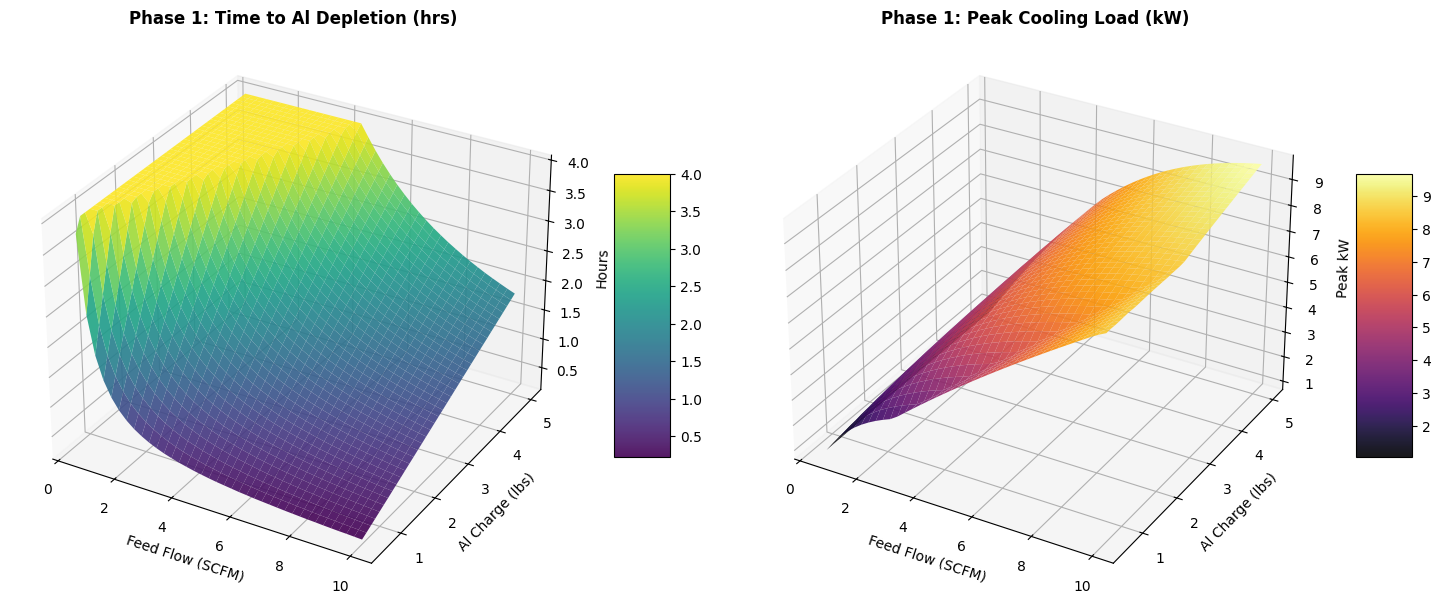

Phase 1 surface complete.


In [7]:
# @title Phase 1 Operating Surface Map
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

N_SURF = 38
print(f"Generating Phase 1 3D Surface ({N_SURF}\xd7{N_SURF} = {N_SURF**2} simulations)...")

flow_range = np.linspace(0.5, 10.0, N_SURF)
al_range   = np.linspace(0.5,  5.0, N_SURF)
F1, A1     = np.meshgrid(flow_range, al_range)
Z_time1    = np.zeros_like(F1)
Z_duty1    = np.zeros_like(F1)

for i in range(N_SURF):
    for j in range(N_SURF):
        p = Phase1Params(gas_flow_scfm=F1[i,j], m_Al_lb=A1[i,j])
        s = execute_phase1_ode(p)

        al_m  = s.y[0]
        mask  = al_m < al_m[0] * 0.01
        Z_time1[i,j] = s.t[mask][0] / 3600.0 if mask.any() else T_SIM_SECONDS / 3600.0

        duty_kW, _ = compute_cooling_profile(s, p.U_jacket, p.T_jacket_in_C, p.cooling_gpm)
        Z_duty1[i,j] = np.max(duty_kW)

fig = plt.figure(figsize=(15, 6), facecolor='#ffffff')

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(F1, A1, Z_time1, cmap=cm.viridis, edgecolor='none', alpha=0.9)
ax1.set_title('Phase 1: Time to Al Depletion (hrs)', fontweight='bold')
ax1.set_xlabel('Feed Flow (SCFM)'); ax1.set_ylabel('Al Charge (lbs)'); ax1.set_zlabel('Hours')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(F1, A1, Z_duty1, cmap=cm.inferno, edgecolor='none', alpha=0.9)
ax2.set_title('Phase 1: Peak Cooling Load (kW)', fontweight='bold')
ax2.set_xlabel('Feed Flow (SCFM)'); ax2.set_ylabel('Al Charge (lbs)'); ax2.set_zlabel('Peak kW')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()
print("Phase 1 surface complete.")


---
# Phase 2: Gasification Syngas Feed

### Cell 6: Phase 2 Process Flow Diagram (PFD)

In Phase 2 the reactor receives a **multi-component syngas stream** directly from the gasifier output — a mixture of H$_2$, CO, CO$_2$, N$_2$, H$_2$O, and HCl. The large inert gas volume (H$_2$, CO, CO$_2$, N$_2$ pass-through) dramatically increases the stripping velocity at the gas-liquid interface, accelerating water vapor entrainment and altering the thermal balance relative to Phase 1.


In [9]:
# @title Phase 2 PFD — Gasifier Feed
from IPython.display import HTML
from graphviz import Digraph

def draw_phase2_pfd():
    dot = Digraph(format='svg')

    # size='10,5!' allows for the wider layout needed for multiple syngas inputs
    dot.attr(rankdir='LR', bgcolor='#fdfefe', fontname='Helvetica', size='10,5!')
    dot.attr('node', shape='box', style='filled, rounded', fillcolor='#ecf0f1',
             fontname='Helvetica', penwidth='1.5')

    # Input Nodes
    dot.node('Gasifier', 'Raw Syngas Source\n(H2, CO, CO2, N2, H2O, HCl)', shape='component', fillcolor='#34495e', fontcolor='white')
    dot.node('Al',       'Aluminum Foil Balls\nCharge (lbs)', fillcolor='#95a5a6')

    # Process Nodes
    dot.node('Reactor',  'Semi-Batch Reactor\nHigh-Inert Stripping', shape='cylinder', fillcolor='#e74c3c', fontcolor='white', height='1.5')

    # Output Nodes
    dot.node('Vent',     'Off-Gas Vent\n(Syngas + Reaction H2 + Steam)', fillcolor='#f1c40f')
    dot.node('Product',  'Brine Phase\nAlCl3 + HCl(aq)', fillcolor='#2ecc71', fontcolor='white')

    # Connections
    dot.edge('Gasifier', 'Reactor', label=' Multi-component Feed')
    dot.edge('Al',       'Reactor', label=' Submerged')
    dot.edge('Reactor',  'Vent',    label=' Enhanced Stripping')
    dot.edge('Reactor',  'Product')

    return dot

# --- FIXED SECTION ---
# Replacing ._repr_svg_() with .pipe().decode()
pfd_graph2 = draw_phase2_pfd()
_svg2 = pfd_graph2.pipe(format='svg').decode('utf-8')

display(HTML(f'<div style="max-width:100%;overflow:auto">{_svg2}</div>'))

In [10]:
# @title Phase 2 ODE Engine (Syngas)
from dataclasses import dataclass

@dataclass
class Phase2Params:
    """Operating conditions for the Phase 2 (gasifier syngas) reactor.

    Feed composition is given as molar fractions.  Only y_hcl is exposed as a
    slider; the other fractions remain at their defaults.  Note: the fractions
    are used as independent scale factors on total SCFM, not normalised, so
    changing y_hcl alone does not reduce the molar flow of other species.
    k_rate has the same 25 °C reference-temperature meaning as in Phase1Params.
    """
    gas_flow_scfm : float = 15.0   # Total syngas flow [SCFM]
    m_Al_lb       : float =  2.0   # Initial Al charge [lbs]
    T_gas_in_C    : float = 150.0  # Feed temperature [°C]
    T_jacket_in_C : float =  20.0  # Cooling-jacket inlet temperature [°C]
    U_jacket      : float = 250.0  # Overall HTC [W/m²K]
    k_rate        : float =  0.15  # Rate constant at 25 °C [(mol/s)/(mol/kg · mol^(2/3))]
    cooling_gpm   : float =  5.0   # Cooling-water flow [US GPM]
    # Syngas molar fractions (each applied independently to total SCFM)
    y_hcl  : float = 0.10
    y_h2o  : float = 0.10
    y_h2   : float = 0.30
    y_co   : float = 0.30
    y_co2  : float = 0.15
    y_n2   : float = 0.05

    # Passivation model
    k_oxide           : float = 0.003  # Al₂O₃ dissolution rate [kg/(mol·s)] at T_REF_K
    enable_passivation: bool  = True   # Simulate induction period from native oxide layer

    def __post_init__(self):
        if self.gas_flow_scfm <= 0:  raise ValueError(f"gas_flow_scfm must be > 0 (got {self.gas_flow_scfm})")
        if self.m_Al_lb <= 0:        raise ValueError(f"m_Al_lb must be > 0 (got {self.m_Al_lb})")
        if self.T_gas_in_C <= 50:    raise ValueError(f"T_gas_in_C must be > 50°C (got {self.T_gas_in_C})")
        if self.T_jacket_in_C <= 0:  raise ValueError(f"T_jacket_in_C must be > 0°C (got {self.T_jacket_in_C})")
        if self.U_jacket <= 0:       raise ValueError(f"U_jacket must be > 0 (got {self.U_jacket})")
        if self.k_rate <= 0:         raise ValueError(f"k_rate must be > 0 (got {self.k_rate})")
        if self.cooling_gpm <= 0:    raise ValueError(f"cooling_gpm must be > 0 (got {self.cooling_gpm})")


def execute_phase2_ode(P: Phase2Params):
    """Integrate the Phase 2 reactor ODEs over T_SIM_SECONDS using the Radau solver.

    State vector:
        y = [n_Al, n_HCl, n_AlCl3, n_H2O, T_C, Σn_H2_vent, Σn_H2O_vent, oxide_frac]
            [mol,  mol,   mol,     mol,   °C,   mol,          mol,        dimensionless]

    Σn_H2_vent accumulates both reaction-generated H2 and syngas pass-through H2.
    Raises RuntimeError if the ODE solver does not converge.
    """
    n_Al_0  = (P.m_Al_lb * LB_TO_KG) / MW['Al']
    n_H2O_0 = (INITIAL_WATER_GAL * 3.78541) / MW['H2O']
    y0 = [n_Al_0, 1e-6, 0.0, n_H2O_0, 20.0, 0.0, 0.0, OXIDE_FRAC_0]

    n_dot_tot = P.gas_flow_scfm * SCFM_TO_MOL_S
    nd_HCl    = n_dot_tot * P.y_hcl
    nd_H2O    = n_dot_tot * P.y_h2o
    nd_H2     = n_dot_tot * P.y_h2
    nd_CO     = n_dot_tot * P.y_co
    nd_CO2    = n_dot_tot * P.y_co2
    nd_N2     = n_dot_tot * P.y_n2
    T_feed_K  = P.T_gas_in_C + 273.15
    mdot_cw   = P.cooling_gpm * GPM_TO_KG_S

    H_feed = (nd_HCl  * shomate_HCl_g.enthalpy_integral(298.15, T_feed_K) +
              nd_H2O  * shomate_H2O_g.enthalpy_integral(298.15, T_feed_K) +
              nd_H2   * shomate_H2_g.enthalpy_integral( 298.15, T_feed_K) +
              nd_CO   * shomate_CO_g.enthalpy_integral(  298.15, T_feed_K) +
              nd_CO2  * shomate_CO2_g.enthalpy_integral( 298.15, T_feed_K) +
              nd_N2   * shomate_N2_g.enthalpy_integral(  298.15, T_feed_K))

    # Total non-condensable molar flow (drives water stripping)
    nd_inerts = nd_H2 + nd_CO + nd_CO2 + nd_N2

    def rhs(t, y):
        n_Al, n_HCl, n_AlCl3, n_H2O, T_C, n_H2v, n_H2Ov, oxide_frac = y
        T_K = T_C + 273.15
        oxide_frac_eff = float(np.clip(oxide_frac, 0.0, 1.0))

        x_water   = n_H2O / max(n_H2O + 2*n_HCl + 4*n_AlCl3, 1e-9)
        P_vap     = vapor_pressure_water_atm(T_C, x_water)
        vent_ratio = P_vap / max(1.0 - P_vap, 0.001)

        n_HCl_eff = max(n_HCl, 0.0)
        n_Al_eff  = max(n_Al,  0.0)
        molality  = n_HCl_eff / max(n_H2O * MW['H2O'], 1e-9)
        k_eff           = arrhenius_k(P.k_rate, T_K)
        # Passivation factor: linear 0→1 as oxide layer dissolves
        pass_factor     = (1.0 - oxide_frac_eff) if P.enable_passivation else 1.0
        r               = k_eff * pass_factor * molality * n_Al_eff**(2.0/3.0) if n_Al_eff > 0.001 else 0.0
        # Oxide dissolution ODE: d(oxide_frac)/dt = −k_ox · m_HCl  (Arrhenius-corrected)
        k_ox_eff        = P.k_oxide * np.exp(-E_A_OX / R_GAS * (1.0/T_K - 1.0/T_REF_K))
        d_oxide_frac_dt = -k_ox_eff * molality if (P.enable_passivation and oxide_frac_eff > 0.0) else 0.0

        # All non-condensables (reaction H2 + syngas pass-through) drive stripping
        dn_H2_rxn   = 1.5 * r
        dn_H2O_vent = (dn_H2_rxn + nd_inerts) * vent_ratio
        dn_H2_vent  = dn_H2_rxn + nd_H2   # includes pass-through H2 in cumulative state

        # Condensation fraction (identical physics to Phase 1)
        nd_tot_feed = nd_HCl + nd_H2O + nd_inerts
        P_H2O_feed  = nd_H2O / max(nd_tot_feed, 1e-9)
        # Use brine P_vap (Raoult-suppressed) not pure-water P_sat
        f_cond      = float(np.clip((P_H2O_feed - P_vap) / P_H2O_feed, 0.0, 1.0)) if P_H2O_feed > 0 else 1.0

        Q_solv_cond   = nd_HCl * dH_solv_HCl_J_mol + nd_H2O * f_cond * dH_cond_H2O_J_mol
        H_bath_demand = (nd_HCl  * Cp_HCl_aq_J_molK * (T_K - 298.15) +
                         nd_H2O  * f_cond * shomate_H2O_l.enthalpy_integral(298.15, T_K))
        q_feed_net    = H_feed + Q_solv_cond - H_bath_demand

        q_rxn      = r * dH_rxn_Al_J_mol
        q_vap_loss = dn_H2O_vent * dH_cond_H2O_J_mol

        nd_uncond = nd_H2O * (1.0 - f_cond)
        q_vent_sensible = (
            (dn_H2_rxn  * shomate_H2_g.cp(T_K) +
             nd_H2       * shomate_H2_g.cp(T_K) +
             nd_CO       * shomate_CO_g.cp(T_K) +
             nd_CO2      * shomate_CO2_g.cp(T_K) +
             nd_N2       * shomate_N2_g.cp(T_K) +
             (dn_H2O_vent + nd_uncond) * shomate_H2O_g.cp(T_K)) * (T_K - 298.15)
        )

        mass_h2o_kg   = max(n_H2O  * MW['H2O'],  0.0)
        mass_salts_kg = max(n_HCl  * MW['HCl'] + n_AlCl3 * MW['AlCl3'], 0.0)
        UA_jkt        = compute_jacket_UA(P.U_jacket, mass_h2o_kg, mass_salts_kg)
        q_cool, _     = lmtd_cooling(T_C, P.T_jacket_in_C, UA_jkt, mdot_cw)

        C_total = (n_H2O  * shomate_H2O_l.cp(T_K) +
                   mass_salts_kg * Cp_salt_aq +
                   n_Al   * MW['Al'] * Cp_Al_solid +
                   mass_vessel_kg * Cp_vessel)

        dT_dt = (q_feed_net + q_rxn - q_vap_loss - q_vent_sensible - q_cool) / max(C_total, 1.0)
        return [-r, nd_HCl - 3*r, r, nd_H2O - dn_H2O_vent, dT_dt, dn_H2_vent, dn_H2O_vent, d_oxide_frac_dt]

    t_eval = np.linspace(0, T_SIM_SECONDS, N_ODE_POINTS)
    sol = solve_ivp(rhs, [0, T_SIM_SECONDS], y0, t_eval=t_eval, method='Radau')
    if not sol.success:
        raise RuntimeError(f"Phase 2 ODE solver failed: {sol.message}")
    return sol


### Cell 8: Phase 2 ODE Reactor Model — Governing Equations

The Phase 2 state vector is identical to Phase 1: $\mathbf{y} = [n_{Al},\, n_{HCl},\, n_{AlCl_3},\, n_{H_2O},\, T_C,\, \Sigma n_{H_2,vent},\, \Sigma n_{H_2O,vent}]$.

**Key distinction from Phase 1:** The vent stream has two H$_2$ sources:
1. *Reaction-generated:* $\dot{n}_{H_2,rxn} = 1.5r$ from $2Al + 6HCl \rightarrow 2AlCl_3 + 3H_2$
2. *Syngas pass-through:* $\dot{n}_{H_2,pass} = \dot{n}_{total} \cdot y_{H_2}$

**Kinetics (Arrhenius-corrected, same form as Phase 1):**

$$r = k_{rate} \cdot e^{-E_A/R\,(1/T - 1/T_{ref})} \cdot m_{HCl} \cdot n_{Al}^{2/3}$$

**Enhanced Water Stripping:**

All non-condensable gases (H$_2$, CO, CO$_2$, N$_2$) contribute to steam stripping, so the total stripping driver is larger than in Phase 1 at the same HCl molar rate:

$$\dot{n}_{H_2O,vent} = \left(\dot{n}_{H_2,rxn} + \dot{n}_{H_2,pass} + \dot{n}_{CO} + \dot{n}_{CO_2} + \dot{n}_{N_2}\right) \cdot \frac{P_{vap}(T, x_{H_2O})}{1 - P_{vap}}$$

**Thermal Balance:**

All syngas species carry sensible heat into the bath via the shared Shomate integral; all vent species (including CO, CO$_2$, N$_2$ pass-throughs) remove sensible heat:

$$\dot{Q}_{feed} = \sum_i \dot{n}_i \int_{298.15}^{T_{feed}} C_{p,i}\,dT \qquad \dot{Q}_{vent,sens} = \sum_i \dot{n}_{i,vent}\, C_{p,i}(T)\,(T - T_{ref})$$

At high syngas flow the vent-sensible term becomes large, creating a net cooling effect from the carrier gas that is absent in Phase 1.

**Note on feed composition:** Slider changes to HCl vol% scale $\dot{n}_{HCl}$ without re-normalising other species — effectively changing total molar throughput.  This is intentional: it allows independent sensitivity analysis of HCl concentration at constant carrier-gas flow.


In [11]:
# @title Phase 2 Output Report & Dashboard
def display_phase2_ui(gas_flow_scfm, m_Al_lb, hcl_pct, T_gas_in_C, T_jacket_in_C,
                      U_jacket, k_rate, cooling_gpm, k_oxide, enable_passivation):
    P   = Phase2Params(gas_flow_scfm=gas_flow_scfm, m_Al_lb=m_Al_lb,
                       y_hcl=hcl_pct/100.0, T_gas_in_C=T_gas_in_C,
                       T_jacket_in_C=T_jacket_in_C, U_jacket=U_jacket,
                       k_rate=k_rate, cooling_gpm=cooling_gpm,
                       k_oxide=k_oxide, enable_passivation=enable_passivation)
    sol = execute_phase2_ode(P)

    risk              = assess_passivation_risk(sol)
    t_pd, ph_sampled  = dynamic_phreeqc_sweep(sol)
    duty_kW, T_cw_out = compute_cooling_profile(sol, P.U_jacket, P.T_jacket_in_C, P.cooling_gpm)

    t_h         = sol.t / 3600.0
    al_lbs      = sol.y[0] * MW['Al'] / LB_TO_KG
    T_C         = sol.y[4]
    oxide_frac  = sol.y[7]
    mass_h2o    = sol.y[3] * MW['H2O']
    mass_salts  = (sol.y[1] * MW['HCl']) + (sol.y[2] * MW['AlCl3'])
    water_level = compute_brine_level(mass_h2o, mass_salts)
    dTdt_arr    = np.gradient(T_C, sol.t)   # deg C/s, same length as t_h

    n_dot_tot = P.gas_flow_scfm * SCFM_TO_MOL_S
    nd_HCl    = n_dot_tot * P.y_hcl;  nd_H2O = n_dot_tot * P.y_h2o
    nd_H2     = n_dot_tot * P.y_h2;   nd_CO  = n_dot_tot * P.y_co
    nd_CO2    = n_dot_tot * P.y_co2;  nd_N2  = n_dot_tot * P.y_n2

    df_in = pd.DataFrame({
        'Source':    ['Syngas HCl', 'Syngas Steam', 'Syngas Inerts (H2,CO,CO2,N2)', 'Initial Al Foil Balls'],
        'Mass (kg)': [(nd_HCl*T_SIM_SECONDS)*MW['HCl'], (nd_H2O*T_SIM_SECONDS)*MW['H2O'], '-', sol.y[0][0]*MW['Al']],
    })

    h2_scf        = sol.y[5][-1] / SCF_TO_MOL   # mol / (mol/SCF) = SCF
    h2o_scf       = sol.y[6][-1] / SCF_TO_MOL
    avg_h2_rxn    = (sol.y[5][-1] - nd_H2*T_SIM_SECONDS) / T_SIM_SECONDS
    df_out = pd.DataFrame({
        'Destination':            ['Product AlCl3', 'Product HCl', 'Remaining Al'],
        'Mass (kg)':              [sol.y[2][-1]*MW['AlCl3'], sol.y[1][-1]*MW['HCl'], sol.y[0][-1]*MW['Al']],
        'Gas Vented (Total SCF)': ['-', '-', '-'],
    })
    df_out.loc[len(df_out)] = ['Off-Gas H2 (rxn+pass-thru)', sol.y[5][-1]*MW['H2'],  f"{h2_scf:.1f} SCF (Rxn: {avg_h2_rxn:.3f} mol/s)"]
    df_out.loc[len(df_out)] = ['Off-Gas H2O(v) Stripped',   sol.y[6][-1]*MW['H2O'], f"{h2o_scf:.1f} SCF"]
    df_out.loc[len(df_out)] = ['Off-Gas CO, CO2, N2',       '-',                      'Pass-through to stack']
    df_out.loc[len(df_out)] = ['Peak Cooling',               f"{np.max(duty_kW):.2f} kW", f"CW outlet peak: {np.max(T_cw_out):.1f} \u00b0C"]

    # \u2500\u2500 Safety / HazOps Risk Summary \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    rc = _RISK_COLORS.get(risk['risk_level'], '#95a5a6')
    ind_str = (f"{risk['breakthrough_time_h']*60:.1f} min"
               if risk['breakthrough_time_h'] is not None
               else 'N/A')
    hcl_str = (f"{risk['hcl_at_breakthrough_mol']:.1f} mol "
               f"(\u2248{risk['q_stored_kJ']:.0f} kJ potential)"
               if risk['hcl_at_breakthrough_mol'] is not None
               else 'N/A')
    warn_html = ''.join(f'<li>{w}</li>' for w in risk['warnings'])
    risk_html = (
        f"<div style='background:{rc};color:white;padding:12px;border-radius:6px;margin:8px 0'>"
        f"<b>Phase 2 Safety Assessment \u2014 Risk Level: {risk['risk_level']}</b><br>"
        f"Induction Period: {ind_str} &nbsp;|&nbsp; HCl at Breakthrough: {hcl_str}<br>"
        f"Peak Temp: {risk['max_temp_C']:.1f}\u00b0C &nbsp;|&nbsp; "
        f"Peak dT/dt: {risk['peak_dTdt_C_per_s']*60:.2f} \u00b0C/min"
        f"</div><ul style='margin:4px 0'>{warn_html}</ul>"
    )

    display(HTML("<h3>Phase 2 Inputs</h3>"));                   display(df_in)
    display(HTML("<h3>Phase 2 Outputs & Vented Stream</h3>")); display(df_out)
    display(HTML(risk_html))

    fig, axs = plt.subplots(4, 2, figsize=(14, 16), facecolor='#ecf0f1')

    axs[0,0].plot(t_h, water_level, color='#007acc', lw=2)
    axs[0,0].set_title('Brine Liquid Level (in)', fontweight='bold'); axs[0,0].set_xlabel('Time (hr)'); axs[0,0].grid(True)

    axs[0,1].plot(t_h, al_lbs, color='#e67e22', lw=2)
    axs[0,1].set_title('Al Foil Balls Inventory (lbs)', fontweight='bold'); axs[0,1].set_xlabel('Time (hr)'); axs[0,1].grid(True)

    axs[1,0].plot(t_h, T_C, color='#c0392b', lw=2, label='Vessel Temp')
    axs[1,0].axhline(115.0, color='red', linestyle=':', lw=1.5, label='115 \u00b0C limit')
    axs[1,0].axhline(T_WARNING_C, color='orange', linestyle='--', lw=1.2, alpha=0.8,
                     label=f'{T_WARNING_C:.0f} \u00b0C warning')
    axs[1,0].set_title('Vessel Temperature (\u00b0C)', fontweight='bold')
    axs[1,0].legend(); axs[1,0].set_xlabel('Time (hr)'); axs[1,0].grid(True)

    axs[1,1].plot(t_h, duty_kW, color='#8e44ad', lw=2, label='Cooling Duty (kW)')
    ax_r = axs[1,1].twinx()
    ax_r.plot(t_h, T_cw_out, '--', color='#1abc9c', lw=1.5, label='CW Outlet (\u00b0C)')
    ax_r.set_ylabel('CW Outlet Temp (\u00b0C)', color='#1abc9c')
    axs[1,1].set_title('Phase 2 Jacket Cooling + CW Outlet Temp', fontweight='bold')
    axs[1,1].legend(loc='upper left'); ax_r.legend(loc='upper right')
    axs[1,1].set_xlabel('Time (hr)'); axs[1,1].grid(True)

    axs[2,0].plot(t_pd, ph_sampled, color='#27ae60', lw=2)
    axs[2,0].set_title('Chemical Speciation (PHREEQC pH)', fontweight='bold')
    axs[2,0].set_ylabel('pH'); axs[2,0].set_xlabel('Operation Time (hr)'); axs[2,0].grid(True)

    axs[2,1].plot(t_h, (sol.y[1]*1000) / (mass_h2o + 1e-9), color='#e74c3c', lw=2)
    axs[2,1].set_title('HCl Aqueous Molality (mmol/kg)', fontweight='bold')
    axs[2,1].set_xlabel('Time (hr)'); axs[2,1].grid(True)

    # \u2500\u2500 NEW: Al\u2082O\u2083 Oxide Layer State (passivation) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    axs[3,0].plot(t_h, oxide_frac * 100.0, color='#2980b9', lw=2)
    axs[3,0].axhline(5.0, color='orange', linestyle='--', lw=1.5, label='Breakthrough (5%)')
    axs[3,0].fill_between(t_h, 0, oxide_frac * 100.0, alpha=0.15, color='#2980b9')
    axs[3,0].set_title('Al\u2082O\u2083 Oxide Layer Remaining (%)', fontweight='bold')
    axs[3,0].set_ylabel('Oxide Remaining (%)'); axs[3,0].set_xlabel('Time (hr)')
    axs[3,0].set_ylim(0, 105); axs[3,0].legend(); axs[3,0].grid(True)

    # \u2500\u2500 NEW: Temperature Rate-of-Rise (thermal runaway indicator) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    axs[3,1].plot(t_h, dTdt_arr * 60.0, color='#d35400', lw=1.5, alpha=0.85)
    axs[3,1].axhline(DTDT_WARNING_C_MIN, color='orange', linestyle='--', lw=1.5,
                     label=f'Warning: {DTDT_WARNING_C_MIN} \u00b0C/min')
    axs[3,1].axhline(0, color='gray', linestyle='-', lw=0.8)
    axs[3,1].set_title('Temperature Rate-of-Rise (Runaway Indicator)', fontweight='bold')
    axs[3,1].set_ylabel('dT/dt (\u00b0C/min)'); axs[3,1].set_xlabel('Time (hr)')
    axs[3,1].legend(); axs[3,1].grid(True)

    plt.tight_layout()
    plt.savefig('phase2_dashboard.png', dpi=110, bbox_inches='tight')
    plt.show()


# \u2500\u2500 Slider-based dashboard \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
_p2_out = widgets.Output()


def _render_phase2(change=None):
    with _p2_out:
        _p2_out.clear_output(wait=True)
        display_phase2_ui(
            _sliders_p2['gas_flow_scfm'].value, _sliders_p2['m_Al_lb'].value,
            _sliders_p2['hcl_pct'].value,        _sliders_p2['T_gas_in_C'].value,
            _sliders_p2['T_jacket_in_C'].value,  _sliders_p2['U_jacket'].value,
            _sliders_p2['k_rate'].value,          _sliders_p2['cooling_gpm'].value,
            _sliders_p2['k_oxide'].value,         _sliders_p2['enable_passivation'].value)


_sliders_p2 = {
    'gas_flow_scfm':      widgets.FloatSlider(value=15.0,  min=1.0,    max=50.0,   step=1.0,
                              description='Syngas Flow (SCFM):',     style={'description_width': 'initial'}),
    'm_Al_lb':            widgets.FloatSlider(value=2.0,   min=0.5,    max=10.0,   step=0.5,
                              description='Initial Al (lbs):',       style={'description_width': 'initial'}),
    'hcl_pct':            widgets.FloatSlider(value=10.0,  min=1.0,    max=50.0,   step=1.0,
                              description='HCl vol%:',               style={'description_width': 'initial'}),
    'T_gas_in_C':         widgets.FloatSlider(value=150.0, min=100.0,  max=300.0,  step=10.0,
                              description='Gas Temp (\u00b0C):',         style={'description_width': 'initial'}),
    'T_jacket_in_C':      widgets.FloatSlider(value=20.0,  min=5.0,    max=50.0,   step=5.0,
                              description='Jacket Inlet (\u00b0C):',   style={'description_width': 'initial'}),
    'U_jacket':           widgets.FloatSlider(value=250.0, min=100.0,  max=1000.0, step=50.0,
                              description='U (W/m\u00b2K):',           style={'description_width': 'initial'}),
    'k_rate':             widgets.FloatSlider(value=0.15,  min=0.01,   max=1.0,    step=0.05,
                              description='k_rate (at 25\u00b0C):',  style={'description_width': 'initial'}),
    'cooling_gpm':        widgets.FloatSlider(value=5.0,   min=1.0,    max=25.0,   step=1.0,
                              description='Cooling (GPM):',           style={'description_width': 'initial'}),
    'k_oxide':            widgets.FloatSlider(value=0.003, min=0.0005, max=0.05,   step=0.0005,
                              description='k_oxide (diss rate):',     style={'description_width': 'initial'}),
    'enable_passivation': widgets.Checkbox(value=True,
                              description='Enable Passivation Model',
                              style={'description_width': 'initial'}),
}
for _w in _sliders_p2.values():
    _w.observe(_render_phase2, names='value')

display(widgets.VBox(list(_sliders_p2.values()) + [_p2_out]))
_render_phase2()  # initial render


### Phase 2: Parametric 3D Surface Plots
Same 38x38 grid approach (1,444 simulations) for Phase 2 syngas feed — maps how Al charge and total syngas flow rate interact to control depletion time and cooling demand under the heavy inert stripping regime. The higher resolution eliminates the faceted appearance seen at 12x12.


Generating Phase 2 3D Surface (38×38 = 1444 simulations)...


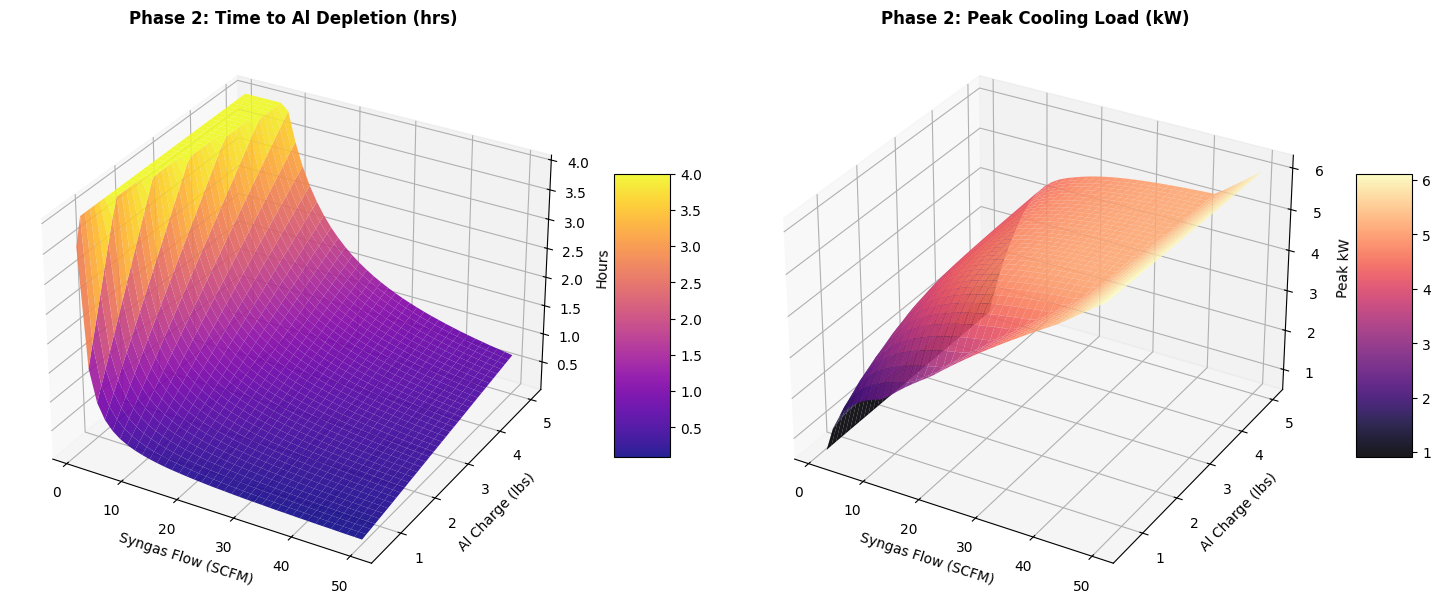

Phase 2 surface complete.


In [12]:
# @title Phase 2 Operating Surface Map
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

N_SURF = 38
print(f"Generating Phase 2 3D Surface ({N_SURF}\xd7{N_SURF} = {N_SURF**2} simulations)...")

flow_range = np.linspace(1.0, 50.0, N_SURF)
al_range   = np.linspace(0.5,  5.0, N_SURF)
F2, A2     = np.meshgrid(flow_range, al_range)
Z_time2    = np.zeros_like(F2)
Z_duty2    = np.zeros_like(F2)

for i in range(N_SURF):
    for j in range(N_SURF):
        p = Phase2Params(gas_flow_scfm=F2[i,j], m_Al_lb=A2[i,j])
        s = execute_phase2_ode(p)

        al_m  = s.y[0]
        mask  = al_m < al_m[0] * 0.01
        Z_time2[i,j] = s.t[mask][0] / 3600.0 if mask.any() else T_SIM_SECONDS / 3600.0

        duty_kW, _ = compute_cooling_profile(s, p.U_jacket, p.T_jacket_in_C, p.cooling_gpm)
        Z_duty2[i,j] = np.max(duty_kW)

fig = plt.figure(figsize=(15, 6), facecolor='#ffffff')

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(F2, A2, Z_time2, cmap=cm.plasma, edgecolor='none', alpha=0.9)
ax1.set_title('Phase 2: Time to Al Depletion (hrs)', fontweight='bold')
ax1.set_xlabel('Syngas Flow (SCFM)'); ax1.set_ylabel('Al Charge (lbs)'); ax1.set_zlabel('Hours')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(F2, A2, Z_duty2, cmap=cm.magma, edgecolor='none', alpha=0.9)
ax2.set_title('Phase 2: Peak Cooling Load (kW)', fontweight='bold')
ax2.set_xlabel('Syngas Flow (SCFM)'); ax2.set_ylabel('Al Charge (lbs)'); ax2.set_zlabel('Peak kW')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()
print("Phase 2 surface complete.")


---
## Comprehensive Engineering Report

This cell executes a full simulation run at default parameters and generates a detailed engineering report. The report includes:

1. **Process Description** — narrative description of each phase and its governing physics
2. **Governing Equations** — all kinetic, thermodynamic, and transport equations with parameter values
3. **Gas Composition Tables** — inlet and outlet flows for both phases in SCFM
4. **Mass Balance Summary** — aluminum consumed, AlCl3 produced, water consumed
5. **Thermal Summary** — peak vessel temperature and jacket cooling duty

### Governing Equations Reference

**Reaction:**
$$2Al_{(s)} + 6HCl_{(g)} \rightarrow 2AlCl_3_{(aq)} + 3H_2_{(g)}, \quad \Delta H_{rxn} = -524.5\,kJ/mol_{Al}$$

**Shrinking-Core Kinetics:**
$$r = k \cdot m_{HCl} \cdot n_{Al}^{2/3} \quad [mol/s]$$
where $m_{HCl}$ is the HCl molality $[mol/kg_{H_2O}]$ and $n_{Al}^{2/3}$ represents available surface area.

**NIST Shomate Heat Capacity:**
$$C_p = A + Bt + Ct^2 + Dt^3 + E/t^2, \quad t = T/1000 \quad [J/mol\cdot K]$$

**Antoine Vapor Pressure with Raoult Suppression:**
$$P_{vap} = \chi_{H_2O} \cdot 10^{8.07131 - 1730.63/(T+233.426)} / 760 \quad [atm]$$

**Water Vapor Stripping Rate:**
$$\dot{n}_{H_2O,strip} = \dot{n}_{dry,vent} \cdot \frac{P_{vap}}{1 - P_{vap}}$$

**Jacket Heat Removal:**
$$\dot{Q}_{cool} = U \cdot A_{wall} \cdot (T_{vessel} - T_{jacket}) \quad [W]$$

**Thermal Energy Balance:**
$$C_{total} \frac{dT}{dt} = \dot{Q}_{feed,net} + \dot{Q}_{rxn} - \dot{Q}_{vap} - \dot{Q}_{vent,sensible} - \dot{Q}_{cool}$$

**SCFM Conversion:** $1\,SCFM = 1.198\,mol/min$ at standard conditions (0\u00b0C, 1 atm)

**Brine Level:**
$$\rho_{brine} = 1000 + 800 \cdot w_{salts}, \quad h = m_{total}/(\rho_{brine} \cdot A_{vessel})$$


In [13]:
# @title Generate Comprehensive Engineering Report (PDF + Markdown)
import os, gc
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from reportlab.lib.pagesizes import letter
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                TableStyle, PageBreak, Image as RLImage, HRFlowable)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch

# Switch to non-interactive Agg backend so figure memory is not held by the
# display subsystem.  We restore the original backend at the very end.
_prev_backend = matplotlib.get_backend()
try:
    plt.switch_backend("Agg")
except Exception:
    pass  # stay with whatever backend is active

print("Running default-parameter simulations for report...")
p1_rep = Phase1Params()
p2_rep = Phase2Params()
sol1_rep = execute_phase1_ode(p1_rep)
sol2_rep = execute_phase2_ode(p2_rep)
print("Simulations complete.")
gc.collect()   # free ODE intermediate arrays before figure generation

def mol_s_to_scfm(x):
    return x * 60.0 / 1.198

def cooling_profile(sol, P):
    mdot = P.cooling_gpm * GPM_TO_KG_S          # GPM -> kg/s
    mass_h2o_arr = sol.y[3] * MW["H2O"]
    mass_sal_arr = (sol.y[1] * MW["HCl"]) + (sol.y[2] * MW["AlCl3"])
    duty = np.zeros(len(sol.t))
    Tout = np.zeros(len(sol.t))
    for i, Tv in enumerate(sol.y[4]):
        UA   = compute_jacket_UA(P.U_jacket, mass_h2o_arr[i], mass_sal_arr[i])
        Q, To = lmtd_cooling(Tv, P.T_jacket_in_C, UA, mdot)
        duty[i] = Q / 1000.0
        Tout[i] = To
    return duty, Tout

duty1, Tcw1 = cooling_profile(sol1_rep, p1_rep)
duty2, Tcw2 = cooling_profile(sol2_rep, p2_rep)
t1_h  = sol1_rep.t / 3600.0
t2_h  = sol2_rep.t / 3600.0
mh2o1 = sol1_rep.y[3] * MW["H2O"]
ms1   = (sol1_rep.y[1] * MW["HCl"]) + (sol1_rep.y[2] * MW["AlCl3"])
mh2o2 = sol2_rep.y[3] * MW["H2O"]
ms2   = (sol2_rep.y[1] * MW["HCl"]) + (sol2_rep.y[2] * MW["AlCl3"])

print("Running PHREEQC sweep (Phase 1)...")
t_pd1, ph1 = dynamic_phreeqc_sweep(sol1_rep)
gc.collect()

print("Running PHREEQC sweep (Phase 2)...")
t_pd2, ph2 = dynamic_phreeqc_sweep(sol2_rep)
gc.collect()

# ---- Numeric summaries (compute before figures so arrays are available) ----
total1   = (p1_rep.gas_flow_scfm * 1.198) / 60.0
nd_hcl1  = total1 * 0.188
nd_h2o1  = total1 * 0.812
peak_T1  = float(np.max(sol1_rep.y[4]))
peak_Q1  = float(np.max(duty1))
Tcw_pk1  = float(np.max(Tcw1))
al_cons1 = (sol1_rep.y[0][0] - sol1_rep.y[0][-1]) * MW["Al"]
alcl3_1  = sol1_rep.y[2][-1] * MW["AlCl3"]

total2   = (p2_rep.gas_flow_scfm * 1.198) / 60.0
nd_hcl2  = total2 * p2_rep.y_hcl
nd_h2o2  = total2 * p2_rep.y_h2o
nd_h2_2  = total2 * p2_rep.y_h2
nd_co_2  = total2 * p2_rep.y_co
nd_co2_2 = total2 * p2_rep.y_co2
nd_n2_2  = total2 * p2_rep.y_n2
peak_T2  = float(np.max(sol2_rep.y[4]))
peak_Q2  = float(np.max(duty2))
Tcw_pk2  = float(np.max(Tcw2))
al_cons2 = (sol2_rep.y[0][0] - sol2_rep.y[0][-1]) * MW["Al"]
alcl3_2  = sol2_rep.y[2][-1] * MW["AlCl3"]

# ---- FIGURE 1: Phase 1 (smaller size + lower DPI to reduce memory footprint) ----
print("Generating Phase 1 figure...")
fig1, ax1 = plt.subplots(3, 2, figsize=(11, 10), facecolor="white")
fig1.suptitle("Phase 1 -- Pure Superheated HCl/Steam Feed (Default Params)", fontsize=12, fontweight="bold")
ax1[0,0].plot(t1_h, compute_brine_level(mh2o1, ms1), color="#007acc", lw=2)
ax1[0,0].set_title("Brine Liquid Level (in)"); ax1[0,0].set_xlabel("Time (hr)"); ax1[0,0].grid(True)
ax1[0,1].plot(t1_h, sol1_rep.y[0]*MW["Al"]/0.453592, color="#e67e22", lw=2)
ax1[0,1].set_title("Al Inventory (lbs)"); ax1[0,1].set_xlabel("Time (hr)"); ax1[0,1].grid(True)
ax1[1,0].plot(t1_h, sol1_rep.y[4], color="#c0392b", lw=2)
ax1[1,0].axhline(115, color="red", ls=":"); ax1[1,0].set_title("Vessel Temp (C)")
ax1[1,0].set_xlabel("Time (hr)"); ax1[1,0].grid(True)
ax1[1,1].plot(t1_h, duty1, color="#8e44ad", lw=2, label="Q_cool (kW)")
ax_r1 = ax1[1,1].twinx()
ax_r1.plot(t1_h, Tcw1, "--", color="#1abc9c", lw=1.5, label="CW Outlet (C)")
ax_r1.set_ylabel("CW Outlet (C)", color="#1abc9c")
ax1[1,1].set_title("Cooling Duty & CW Outlet (LMTD)")
ax1[1,1].legend(loc="upper left"); ax_r1.legend(loc="upper right")
ax1[1,1].set_xlabel("Time (hr)"); ax1[1,1].grid(True)
ax1[2,0].plot(t_pd1, ph1, color="#27ae60", lw=2.5)
ax1[2,0].set_title("PHREEQC pH"); ax1[2,0].set_xlabel("Time (hr)"); ax1[2,0].grid(True)
ax1[2,1].plot(t1_h, (sol1_rep.y[1]*1000)/(mh2o1+1e-6), color="#e74c3c", lw=2)
ax1[2,1].set_title("HCl Molality (mmol/kg)"); ax1[2,1].set_xlabel("Time (hr)"); ax1[2,1].grid(True)
plt.tight_layout()
fig1.savefig("/tmp/phase1_report.png", dpi=90, bbox_inches="tight")
plt.close(fig1)    # CRITICAL: release figure memory before building fig2
del fig1, ax1, ax_r1
gc.collect()
print("Phase 1 figure saved.")

# ---- FIGURE 2: Phase 2 ----
print("Generating Phase 2 figure...")
fig2, ax2 = plt.subplots(3, 2, figsize=(11, 10), facecolor="white")
fig2.suptitle("Phase 2 -- Gasification Syngas Feed (Default Params)", fontsize=12, fontweight="bold")
ax2[0,0].plot(t2_h, compute_brine_level(mh2o2, ms2), color="#007acc", lw=2)
ax2[0,0].set_title("Brine Liquid Level (in)"); ax2[0,0].set_xlabel("Time (hr)"); ax2[0,0].grid(True)
ax2[0,1].plot(t2_h, sol2_rep.y[0]*MW["Al"]/0.453592, color="#e67e22", lw=2)
ax2[0,1].set_title("Al Inventory (lbs)"); ax2[0,1].set_xlabel("Time (hr)"); ax2[0,1].grid(True)
ax2[1,0].plot(t2_h, sol2_rep.y[4], color="#c0392b", lw=2)
ax2[1,0].axhline(115, color="red", ls=":"); ax2[1,0].set_title("Vessel Temp (C)")
ax2[1,0].set_xlabel("Time (hr)"); ax2[1,0].grid(True)
ax2[1,1].plot(t2_h, duty2, color="#8e44ad", lw=2, label="Q_cool (kW)")
ax_r2 = ax2[1,1].twinx()
ax_r2.plot(t2_h, Tcw2, "--", color="#1abc9c", lw=1.5, label="CW Outlet (C)")
ax_r2.set_ylabel("CW Outlet (C)", color="#1abc9c")
ax2[1,1].set_title("Cooling Duty & CW Outlet (LMTD)")
ax2[1,1].legend(loc="upper left"); ax_r2.legend(loc="upper right")
ax2[1,1].set_xlabel("Time (hr)"); ax2[1,1].grid(True)
ax2[2,0].plot(t_pd2, ph2, color="#27ae60", lw=2.5)
ax2[2,0].set_title("PHREEQC pH"); ax2[2,0].set_xlabel("Time (hr)"); ax2[2,0].grid(True)
ax2[2,1].plot(t2_h, (sol2_rep.y[1]*1000)/(mh2o2+1e-6), color="#e74c3c", lw=2)
ax2[2,1].set_title("HCl Molality (mmol/kg)"); ax2[2,1].set_xlabel("Time (hr)"); ax2[2,1].grid(True)
plt.tight_layout()
fig2.savefig("/tmp/phase2_report.png", dpi=90, bbox_inches="tight")
plt.close(fig2)    # CRITICAL: release figure memory before starting PDF build
del fig2, ax2, ax_r2
gc.collect()
print("Phase 2 figure saved.")

# ---- BUILD PDF ----
print("Building PDF...")
try:
    doc = SimpleDocTemplate("HCl_Reactor_Engineering_Report.pdf", pagesize=letter,
        rightMargin=0.75*inch, leftMargin=0.75*inch,
        topMargin=0.75*inch, bottomMargin=0.75*inch)
    styles = getSampleStyleSheet()
    H1   = ParagraphStyle("H1", parent=styles["Heading1"], fontSize=14, spaceAfter=6)
    H2   = ParagraphStyle("H2", parent=styles["Heading2"], fontSize=12, spaceAfter=4)
    H3   = ParagraphStyle("H3", parent=styles["Heading3"], fontSize=10, spaceAfter=3)
    body = styles["Normal"]; body.leading = 14

    def Par(text, sty=None):
        return Paragraph(text, sty or body)

    def tbl(data, cw=None):
        t = Table(data, colWidths=cw, repeatRows=1)
        t.setStyle(TableStyle([
            ("BACKGROUND",    (0,0), (-1,0), colors.HexColor("#2c3e50")),
            ("TEXTCOLOR",     (0,0), (-1,0), colors.white),
            ("FONTNAME",      (0,0), (-1,0), "Helvetica-Bold"),
            ("FONTSIZE",      (0,0), (-1,-1), 9),
            ("ROWBACKGROUNDS",(0,1), (-1,-1), [colors.white, colors.HexColor("#f2f2f2")]),
            ("GRID",          (0,0), (-1,-1), 0.5, colors.grey),
            ("TOPPADDING",    (0,0), (-1,-1), 4),
            ("BOTTOMPADDING", (0,0), (-1,-1), 4),
        ]))
        return t

    def img_block(path, w=6.5*inch):
        if os.path.exists(path):
            return RLImage(path, width=w, height=w*0.9)
        return Par(f"[Figure not found: {path}]")

    story = []
    story.append(Par("<font size=18><b>HCl-Aluminum Reactor Model</b></font>", styles["Title"]))
    story.append(Par("<font size=12>Comprehensive Engineering Report</font>", styles["Title"]))
    story.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor("#2c3e50")))
    story.append(Spacer(1, 0.2*inch))
    story.append(Par("Semi-batch synthesis of aqueous AlCl<sub>3</sub> by HCl attack on solid aluminum foil balls, two feed scenarios."))
    story.append(Spacer(1, 0.2*inch))

    story.append(Par("1. Governing Chemistry", H1))
    story.append(Par("<b>2Al(s) + 6HCl(g) &#8594; 2AlCl<sub>3</sub>(aq) + 3H<sub>2</sub>(g)</b>&nbsp;&nbsp; dHrxn = -531.5 kJ/mol-Al (NIST)"))
    story.append(Par("HCl solvation: dH = -74.84 kJ/mol&nbsp;&nbsp; H<sub>2</sub>O condensation: dH = -44.0 kJ/mol (298 K ref)"))
    story.append(Spacer(1, 0.15*inch))

    story.append(Par("2. Governing Equations", H1))
    eqs = [
        ["Equation", "Formula", "Notes"],
        ["Shrinking-core kinetics", "r = k * m_HCl * n_Al^(2/3) [mol/s]", "m_HCl = molality [mol/kg-H2O]"],
        ["Shomate Cp",             "Cp = A+Bt+Ct2+Dt3+E/t2, t=T/1000", "All gas/liquid species"],
        ["Raoult vapor pressure",  "P_vap = x_H2O * Antoine(T)/760",    "x_H2O accounts for salts"],
        ["Water stripping",        "dn_H2O_vent = dn_dry * Pvap/(1-Pvap)","All inerts count in Phase 2"],
        ["Cooling (NTU-LMTD)",     "NTU = UA/(mdot*Cp); eff=1-exp(-NTU)","Q = eff*mdot*Cp*(T-Tin)"],
        ["CW outlet temp",         "Tcw_out = Tcw_in + Q/(mdot*Cp)",    "Derived from energy balance"],
        ["Energy balance",         "C_tot*dT/dt = Qfeed+Qrxn-Qvap-Qvent-Qcool", "ODE state"],
        ["Brine density",          "rho = 1000 + 560*w + 320*w^2 [kg/m3]", "AlCl3 brine quadratic fit"],
        ["PHREEQC pH",             "15-point sweep from Al3+/Cl- molalities","LLNL database"],
    ]
    story.append(tbl(eqs, [1.8*inch, 2.8*inch, 2.0*inch]))
    story.append(Spacer(1, 0.2*inch))

    story.append(Par("3. Key Assumptions", H1))
    assum = [
        ["#", "Assumption", "Implication"],
        ["1", "Bath is perfectly mixed (CSTR)",          "No spatial gradients"],
        ["2", "Gas-liquid equilibrium at surface",       "Valid at low sparging velocity"],
        ["3", "Al balls are perfect spheres",           "Foil geometry differs; affects n^(2/3)"],
        ["4 (RESOLVED)", "Arrhenius T-correction added to k_rate", "k_eff = k_rate * exp(-Ea/R*(1/T-1/Tref))"],
        ["5", "Cp_cw = 4182 J/(kg K), rho=1000 kg/m3", "Adjust for glycol coolant"],
        ["6", "UA based on live wetted wall area",      "Calibrate U against real data"],
        ["7", "SCFM at 60F/1 atm (1 SCFM = 1.198 mol/min)","Industrial standard"],
        ["8", "Phase 1 feed: 18.8% HCl / 81.2% steam", "From 32 wt% HCl flash"],
        ["9", "dHrxn constant at 298 K value",          "Small Kirchhoff correction neglected"],
    ]
    story.append(tbl(assum, [0.3*inch, 3.0*inch, 2.9*inch]))
    story.append(PageBreak())

    story.append(Par("4. Phase 1 Results (Default Parameters)", H1))
    mdot1_kgs = p1_rep.cooling_gpm * GPM_TO_KG_S
    p1p = [
        ["Parameter", "Value"],
        ["Feed flow",   f"{p1_rep.gas_flow_scfm:.1f} SCFM total"],
        ["HCl rate",   f"{mol_s_to_scfm(nd_hcl1):.4f} SCFM ({nd_hcl1*60:.4f} mol/min)"],
        ["Steam rate",  f"{mol_s_to_scfm(nd_h2o1):.4f} SCFM"],
        ["Al charged",  f"{sol1_rep.y[0][0]*MW['Al']:.3f} kg ({p1_rep.m_Al_lb} lbs)"],
        ["Jacket inlet",f"{p1_rep.T_jacket_in_C:.0f} C"],
        ["U coefficient",f"{p1_rep.U_jacket:.0f} W/(m2 K)"],
        ["Cooling GPM", f"{p1_rep.cooling_gpm:.1f} GPM ({mdot1_kgs:.5f} kg/s)"],
        ["k_rate",      f"{p1_rep.k_rate:.2f}"],
    ]
    p1r = [
        ["Result", "Value"],
        ["Al consumed",      f"{al_cons1:.3f} kg"],
        ["AlCl3 produced",   f"{alcl3_1:.3f} kg"],
        ["Al remaining",     f"{sol1_rep.y[0][-1]*MW['Al']:.4f} kg"],
        ["Peak vessel temp", f"{peak_T1:.1f} C"],
        ["Peak cooling duty",f"{peak_Q1:.2f} kW"],
        ["Peak CW outlet",   f"{Tcw_pk1:.1f} C"],
    ]
    story.append(Par("Parameters:", H3)); story.append(tbl(p1p, [3*inch, 3.5*inch]))
    story.append(Spacer(1, 0.1*inch))
    story.append(Par("Results:",    H3)); story.append(tbl(p1r, [3*inch, 3.5*inch]))
    story.append(Spacer(1, 0.1*inch))
    story.append(Par("Phase 1 Dashboard Plots:", H3))
    story.append(img_block("/tmp/phase1_report.png"))

    story.append(PageBreak())
    story.append(Par("5. Phase 2 Results (Default Parameters)", H1))
    mdot2_kgs = p2_rep.cooling_gpm * GPM_TO_KG_S
    p2p = [
        ["Parameter", "Value"],
        ["Syngas total",    f"{p2_rep.gas_flow_scfm:.1f} SCFM"],
        ["HCl",            f"{p2_rep.y_hcl*100:.0f} vol% = {mol_s_to_scfm(nd_hcl2):.4f} SCFM"],
        ["Steam",          f"{p2_rep.y_h2o*100:.0f} vol% = {mol_s_to_scfm(nd_h2o2):.4f} SCFM"],
        ["H2 pass-through",f"{p2_rep.y_h2*100:.0f} vol% = {mol_s_to_scfm(nd_h2_2):.4f} SCFM"],
        ["CO pass-through",f"{p2_rep.y_co*100:.0f} vol% = {mol_s_to_scfm(nd_co_2):.4f} SCFM"],
        ["CO2 pass-through",f"{p2_rep.y_co2*100:.0f} vol% = {mol_s_to_scfm(nd_co2_2):.4f} SCFM"],
        ["N2 pass-through", f"{p2_rep.y_n2*100:.0f} vol% = {mol_s_to_scfm(nd_n2_2):.4f} SCFM"],
        ["Al charged",     f"{sol2_rep.y[0][0]*MW['Al']:.3f} kg ({p2_rep.m_Al_lb} lbs)"],
        ["Cooling GPM",    f"{p2_rep.cooling_gpm:.1f} GPM ({mdot2_kgs:.5f} kg/s)"],
    ]
    p2r = [
        ["Result", "Value"],
        ["Al consumed",      f"{al_cons2:.3f} kg"],
        ["AlCl3 produced",   f"{alcl3_2:.3f} kg"],
        ["Al remaining",     f"{sol2_rep.y[0][-1]*MW['Al']:.4f} kg"],
        ["Peak vessel temp", f"{peak_T2:.1f} C"],
        ["Peak cooling duty",f"{peak_Q2:.2f} kW"],
        ["Peak CW outlet",   f"{Tcw_pk2:.1f} C"],
    ]
    story.append(Par("Parameters:", H3)); story.append(tbl(p2p, [3*inch, 3.5*inch]))
    story.append(Spacer(1, 0.1*inch))
    story.append(Par("Results:",    H3)); story.append(tbl(p2r, [3*inch, 3.5*inch]))
    story.append(Spacer(1, 0.1*inch))
    story.append(Par("Phase 2 Dashboard Plots:", H3))
    story.append(img_block("/tmp/phase2_report.png"))

    story.append(PageBreak())
    story.append(Par("6. Physical Constants & Unit Conversions", H1))
    consts = [
        ["Quantity", "Value", "Notes"],
        ["SCFM to mol/min",          "1.198",           "60F, 1 atm industrial std"],
        ["GPM to kg/s (water)",      "0.06309",         "rho=1000 kg/m3"],
        ["Cp water",                 "4182 J/(kg K)",   "Coolant"],
        ["MW Al/HCl/AlCl3/H2O/H2",  "26.98/36.46/133.34/18.02/2.016 g/mol",""],
        ["Vessel diameter",          f"{vessel_dia_m*100:.1f} cm ({vessel_dia_m/0.0254:.1f} in)",""],
        ["Vessel height (shell)",    f"{vessel_height_m:.4f} m ({vessel_height_m/0.0254:.0f} in)","Max jacket height"],
        ["Vessel mass",              f"{mass_vessel_kg} kg","Thermal mass"],
        ["Cp vessel (steel)",        f"{Cp_vessel} J/(kg K)",""],
        ["Cp aqueous salts",         f"{Cp_salt_aq} J/(kg K)",""],
        ["dH_rxn (Al)",              "-531.5 kJ/mol-Al (NIST, aq-phase rxn)","Exothermic"],
        ["dH_solv HCl",              "-74.84 kJ/mol",""],
        ["dH_cond H2O",              "-44.0 kJ/mol (at 298 K)","matches code constant"],
    ]
    story.append(tbl(consts, [2.4*inch, 2.5*inch, 1.8*inch]))

    doc.build(story)
    print("PDF report saved: HCl_Reactor_Engineering_Report.pdf")

except Exception as e:
    import traceback
    print(f"ERROR building PDF: {e}")
    traceback.print_exc()
finally:
    gc.collect()

# ---- Markdown backup ----
try:
    with open("HCl_Reactor_Engineering_Report.md", "w") as f:
        f.write(f"""# HCl-Aluminum Reactor Model: Engineering Report

## Chemistry
2Al(s) + 6HCl(g) -> 2AlCl3(aq) + 3H2(g)    dHrxn = -524.5 kJ/mol-Al

## Key Equations
- Kinetics: r = k * m_HCl * n_Al^(2/3)  [mol/s]
- Shomate Cp: Cp = A+Bt+Ct2+Dt3+E/t2, t=T/1000
- Raoult: P_vap = x_H2O * Antoine(T)/760
- Stripping: dn_H2O_vent = dn_dry * Pvap/(1-Pvap)
- Cooling NTU: NTU=UA/(mdot*Cp), eff=1-exp(-NTU), Q=eff*mdot*Cp*(T-Tin)
- CW outlet: T_cw_out = T_cw_in + Q/(mdot*Cp)
- ODE: C_tot*dT/dt = Qfeed+Qrxn-Qvap-Qvent-Qcool

## Phase 1 Results (Default)
- HCl feed:       {mol_s_to_scfm(nd_hcl1):.4f} SCFM
- Steam feed:     {mol_s_to_scfm(nd_h2o1):.4f} SCFM
- Al charged:     {sol1_rep.y[0][0]*MW["Al"]:.3f} kg
- AlCl3 produced: {alcl3_1:.3f} kg
- Peak temp:      {peak_T1:.1f} C
- Peak cooling:   {peak_Q1:.2f} kW
- Peak CW outlet: {Tcw_pk1:.1f} C

## Phase 2 Results (Default)
- Syngas:         {p2_rep.gas_flow_scfm} SCFM total, {p2_rep.y_hcl*100:.0f}% HCl
- HCl rate:       {mol_s_to_scfm(nd_hcl2):.4f} SCFM
- Al charged:     {sol2_rep.y[0][0]*MW["Al"]:.3f} kg
- AlCl3 produced: {alcl3_2:.3f} kg
- Peak temp:      {peak_T2:.1f} C
- Peak cooling:   {peak_Q2:.2f} kW
- Peak CW outlet: {Tcw_pk2:.1f} C
""")
    print("Markdown saved: HCl_Reactor_Engineering_Report.md")
except Exception as e:
    print(f"ERROR saving Markdown: {e}")

# Restore the original matplotlib backend so subsequent cells still display inline
try:
    plt.switch_backend(_prev_backend)
except Exception:
    pass

print("\nReport generation complete.")
print("To export full notebook with rendered plots:")
print("  File > Download > Download .ipynb")
print("  Or: !jupyter nbconvert --to html HCl_Reactor_Model_Final.ipynb")


Running default-parameter simulations for report...
Simulations complete.
Running PHREEQC sweep (Phase 1)...
Running PHREEQC sweep (Phase 2)...
Generating Phase 1 figure...
Phase 1 figure saved.
Generating Phase 2 figure...
Phase 2 figure saved.
Building PDF...
PDF report saved: HCl_Reactor_Engineering_Report.pdf
Markdown saved: HCl_Reactor_Engineering_Report.md

Report generation complete.
To export full notebook with rendered plots:
  File > Download > Download .ipynb
  Or: !jupyter nbconvert --to html HCl_Reactor_Model_Final.ipynb
